>>>[Helpers](#scrollTo=GZU-NwJPAo6g)

>[Import Datasets](#scrollTo=4n8HZTneSZ6g)

>>>[Prepare Quantitativbe-partecipants Database](#scrollTo=NgUXhNbXTGkZ)

>>>[Prepare Qualitative-Questionary Database](#scrollTo=Bn1u-5UfTBLD)

>[Context Switching](#scrollTo=PS3WGd1d4geY)

>>>[Quantitative](#scrollTo=EYgtGas1-QJf)

>>>[Qualitative](#scrollTo=rh-rhLyJ-Xz_)

>[Homework](#scrollTo=L2j7_DoVHtFn)

>>>[Quantitative](#scrollTo=dMyRRZAjH9_W)

>>>[Qualitative](#scrollTo=JxHS83qRH-pf)

>[GI](#scrollTo=izqMugAeN2iv)

>>>[time x generation](#scrollTo=P8k15rpvPykR)

>[DW](#scrollTo=l8VYoMk9NxR-)

>[Demographic](#scrollTo=8CCjtuX0jW26)



In [52]:
from google.colab import drive  #connect collab with drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch

### Helpers

In [54]:
# format: min:sec
# transfrom in seconds only
def convert_min_sec_to_seconds(time_str):
    try:
        # format can be min:sec OR min:sec:milliseconds (can discard milliseconds)
        # Split on ':' if it's in 'min:sec' format, otherwise assume it's just seconds
        if ':' in time_str:
            # if there are 2 ':' the format is min:sec:milliseconds
            if time_str.count(':') == 2:
                minutes, seconds, milliseconds = map(int, time_str.split(':'))
            else: # format is min:sec
              minutes, seconds = map(int, time_str.split(':'))
            return minutes * 60 + seconds
        else:
            return int(time_str)
    except ValueError:
        return np.nan

# **Import Datasets**

In [55]:
partecipants_db_path = "/content/drive/MyDrive/AIfred/ICRA/DataAnalysis/Partecipants.csv"
questionaries_db_path = "/content/drive/MyDrive/AIfred/ICRA/DataAnalysis/QualitativeResposnses.csv"

In [56]:
p_db = pd.read_csv(partecipants_db_path)
q_db = pd.read_csv(questionaries_db_path)

### <font color="green">Prepare Quantitativbe-partecipants Database</font>

In [57]:
p_db

,ID,Participant,Condition,t HM,t GI,t DW,t DW opposite,t HW no help,HW nS,DW nS,...,chat gpt rank p3,aIfred rank p3,HW grade 1,HW grade 2,HW grade 3,HW grade 4,HW grade no help 1,HW grade no help 2,HW grade no help 3,HW grade no help 4
0,1,Edu,Ex,03:31,10:00,04:50,01:20,06:00,2,0,...,2,1,7.2,6.1,6.1,6.6,8.3,8.3,8.3,7.8
1,2,Saleh,Ex,05:14,00:35,02:13,06:48,00:05,4,0,...,1,2,8.3,5.5,6.6,7.8,7.8,7.8,7.8,7.2
2,3,Amir,Ex,02:10,03:00,06:13,01:29,01:00,4,0,...,3,1,5.6,6.3,7.5,4.7,8.8,8.9,8.9,8.8
3,4,Reihana,Ex,04:10,01:20,05:20,30:16:00,04:00,4,0,...,2,1,8.8,8.9,8.3,8.8,8.8,8.9,8.8,8.9
4,5,Farah,Ex,03:21,01:43,09:14,03:59,02:30,4,0,...,2,1,7.2,8.9,7.8,7.8,8.3,8.4,8.9,8.3
5,6,Aurora,Ex,16:05,00:30,09:40,02:25,00:33,8,0,...,2,1,1.4,1.3,1.0,1.7,2.1,2.1,2.1,2.1
6,7,Valentina,Ex,08:43,07:39,05:20,02:50,05:20,2,0,...,1,2,3.2,3.2,3.3,3.3,2.7,2.7,2.7,1.6
7,8,Francesca,Ex,04:28,03:09,07:17,05:41,02:38,0,0,...,2,1,6.1,7.2,7.8,6.7,8.9,8.9,8.9,8.9
8,9,Sam,Ex,03:53,01:15,12:00,02:40,04:30,6,0,...,3,1,8.9,8.9,8.9,8.9,8.9,8.9,8.9,8.9
9,10,Maika,Ex,05:02,00:39,03:52,02:00,04:40,10,0,...,2,1,8.9,8.9,8.9,8.3,8.9,7.2,8.9,8.3


In [58]:
# SPLIT p_db INTO 2 DATABASES BASED ON CONDITION (Ex or Ct)
ex_p = p_db[p_db['Condition'] == 'Ex']
ct_p = p_db[p_db['Condition'] == 'Ct']
# Drop 'Condition' column
ex_p = ex_p.drop(columns=['Condition'])
ct_p = ct_p.drop(columns=['Condition'])

print('Ex Condition DataFrame (ex_p):')
display(ex_p)

print('\nCt Condition DataFrame (ct_p):')
display(ct_p)

Ex Condition DataFrame (ex_p):


,ID,Participant,t HM,t GI,t DW,t DW opposite,t HW no help,HW nS,DW nS,DW opposite nS,...,chat gpt rank p3,aIfred rank p3,HW grade 1,HW grade 2,HW grade 3,HW grade 4,HW grade no help 1,HW grade no help 2,HW grade no help 3,HW grade no help 4
0,1,Edu,03:31,10:00,04:50,01:20,06:00,2,0,48,...,2,1,7.2,6.1,6.1,6.6,8.3,8.3,8.3,7.8
1,2,Saleh,05:14,00:35,02:13,06:48,00:05,4,0,139,...,1,2,8.3,5.5,6.6,7.8,7.8,7.8,7.8,7.2
2,3,Amir,02:10,03:00,06:13,01:29,01:00,4,0,39,...,3,1,5.6,6.3,7.5,4.7,8.8,8.9,8.9,8.8
3,4,Reihana,04:10,01:20,05:20,30:16:00,04:00,4,0,370,...,2,1,8.8,8.9,8.3,8.8,8.8,8.9,8.8,8.9
4,5,Farah,03:21,01:43,09:14,03:59,02:30,4,0,86,...,2,1,7.2,8.9,7.8,7.8,8.3,8.4,8.9,8.3
5,6,Aurora,16:05,00:30,09:40,02:25,00:33,8,0,60,...,2,1,1.4,1.3,1.0,1.7,2.1,2.1,2.1,2.1
6,7,Valentina,08:43,07:39,05:20,02:50,05:20,2,0,96,...,1,2,3.2,3.2,3.3,3.3,2.7,2.7,2.7,1.6
7,8,Francesca,04:28,03:09,07:17,05:41,02:38,0,0,100,...,2,1,6.1,7.2,7.8,6.7,8.9,8.9,8.9,8.9
8,9,Sam,03:53,01:15,12:00,02:40,04:30,6,0,27,...,3,1,8.9,8.9,8.9,8.9,8.9,8.9,8.9,8.9
9,10,Maika,05:02,00:39,03:52,02:00,04:40,10,0,41,...,2,1,8.9,8.9,8.9,8.3,8.9,7.2,8.9,8.3



Ct Condition DataFrame (ct_p):


,ID,Participant,t HM,t GI,t DW,t DW opposite,t HW no help,HW nS,DW nS,DW opposite nS,...,chat gpt rank p3,aIfred rank p3,HW grade 1,HW grade 2,HW grade 3,HW grade 4,HW grade no help 1,HW grade no help 2,HW grade no help 3,HW grade no help 4
18,1,Farah,01:00,02:38,02:50,03:00,03:08,6,32,0,...,3,1,7.8,7.8,7.2,7.8,3.3,3.8,3.8,3.8
19,2,Saleh,12:00,05:20,04:50,07:25,01:54,102,200,0,...,2,1,2.9,5.5,8.7,8.2,7.3,6.0,2.1,5.5
20,3,Maika,02:22,02:49,02:31,13:06,09:32,119,112,0,...,2,1,7.8,7.8,7.8,7.2,3.3,3.3,3.3,3.8
21,4,Sam,02:52,05:08,01:59,06:07,02:33,4,61,0,...,2,1,8.9,8.9,8.9,8.9,8.9,8.9,8.9,8.9
22,5,Suzan,04:37,04:28,10:27,07:31,01:04,153,208,0,...,2,1,7.8,7.8,7.8,7.2,6.1,6.1,6.1,6.1
23,6,Luca,03:58,05:00,18:00,08:40,00:17,47,202,4,...,1,2,7.8,6.1,8.3,7.2,2.7,2.7,2.7,2.7
24,7,Valentina,06:38,05:36,04:10,15:36,04:11,82,160,0,...,2,1,4.4,4.4,4.4,4.4,2.1,2.1,2.1,2.1
25,8,Ines,02:36,03:27,01:44,04:48,01:06,2,16,0,...,2,1,8.3,8.4,8.3,8.9,7.2,5.5,7.2,7.2
26,9,Noelia,01:36,03:47,07:51,07:29,00:11,32,176,0,...,2,1,6.7,7.1,6.8,6.1,2.1,1.3,2.1,2.1
27,10,Paula,01:48,02:49,01:29,14:08,01:00,10,20,0,...,2,1,8.8,8.9,1.0,5.0,1.0,5.0,8.9,8.8


### <font color="green">Prepare Qualitative-Questionary Database</font>

In [59]:
q_db

,Condition,QID1_1 (Task Productivity),QID1_2 (Task Productivity),QID1_3 (Task Productivity),QID1_4 (Task Productivity),QID1_5 (Task Productivity),QID1_6 (Task Innovation),QID1_7 (Task Innovation),QID1_8 (Task Innovation),QID1_9 (Information Quality),...,QID1_21 (Cognitive Demand),QID1_22 (User Satisfaction),QID1_23 (User Satisfaction),QID1_24 (User Satisfaction),QID1_25 (User Satisfaction),QID1_26 (User Preferences),QID2_1 (Perceived Context Switching),QID2_2 (Perceived Context Switching),QID2_3 (Perceived Context Switching),QID2_4 (Perceived Context Switching)
0,Ex,Somewhat agree,Neither agree nor disagree,Neither agree nor disagree,Strongly agree,Neither agree nor disagree,Strongly agree,Strongly agree,Neither agree nor disagree,Neither agree nor disagree,...,Neither agree nor disagree,Somewhat agree,Somewhat agree,Neither agree nor disagree,Somewhat agree,Strongly agree,Strongly agree,Strongly agree,Somewhat agree,Somewhat agree
1,Ex,Somewhat agree,Somewhat agree,Somewhat agree,Strongly agree,Strongly agree,Somewhat agree,Somewhat agree,Somewhat agree,Strongly agree,...,Neither agree nor disagree,Somewhat agree,Somewhat agree,Strongly agree,Somewhat agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree
2,Ex,Strongly agree,Somewhat agree,Neither agree nor disagree,Strongly agree,Somewhat agree,Strongly disagree,Strongly agree,Somewhat agree,Strongly agree,...,Strongly disagree,Strongly agree,Somewhat agree,Somewhat agree,Somewhat agree,Strongly agree,Neither agree nor disagree,Strongly agree,Somewhat agree,Somewhat agree
3,Ex,Neither agree nor disagree,Somewhat agree,Strongly agree,Strongly agree,Somewhat agree,Somewhat agree,Strongly agree,Somewhat agree,Neither agree nor disagree,...,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree
4,Ex,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Strongly agree,...,Neither agree nor disagree,Strongly agree,Somewhat disagree,Strongly agree,Strongly agree,Strongly agree,Somewhat agree,Strongly agree,Neither agree nor disagree,Somewhat agree
5,Ex,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Somewhat agree,Strongly agree,Strongly agree,Somewhat agree,...,Neither agree nor disagree,Somewhat agree,Somewhat agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree
6,Ex,Strongly agree,Strongly agree,Somewhat agree,Somewhat agree,Strongly agree,Neither agree nor disagree,Strongly agree,Somewhat agree,Somewhat agree,...,Somewhat disagree,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree
7,Ex,Somewhat disagree,Somewhat disagree,Somewhat disagree,Somewhat agree,Neither agree nor disagree,Somewhat agree,Somewhat agree,Somewhat agree,Strongly agree,...,Strongly disagree,Somewhat agree,Neither agree nor disagree,Somewhat agree,Somewhat agree,Somewhat disagree,Strongly agree,Somewhat disagree,Neither agree nor disagree,Somewhat agree
8,Ex,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Strongly agree,Somewhat agree,Strongly agree,...,Neither agree nor disagree,Strongly agree,Somewhat agree,Strongly agree,Somewhat agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree
9,Ex,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,...,Strongly disagree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Somewhat agree,Strongly agree


In [60]:
q_db.describe()

,Condition,QID1_1 (Task Productivity),QID1_2 (Task Productivity),QID1_3 (Task Productivity),QID1_4 (Task Productivity),QID1_5 (Task Productivity),QID1_6 (Task Innovation),QID1_7 (Task Innovation),QID1_8 (Task Innovation),QID1_9 (Information Quality),...,QID1_21 (Cognitive Demand),QID1_22 (User Satisfaction),QID1_23 (User Satisfaction),QID1_24 (User Satisfaction),QID1_25 (User Satisfaction),QID1_26 (User Preferences),QID2_1 (Perceived Context Switching),QID2_2 (Perceived Context Switching),QID2_3 (Perceived Context Switching),QID2_4 (Perceived Context Switching)
count,36,36,36,36,36,36,36,36,36,36,...,36,36,36,36,36,36,36,36,36,36
unique,2,4,4,4,4,5,5,5,4,5,...,5,5,5,4,4,5,4,4,4,3
top,Ex,Strongly agree,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Strongly agree,Somewhat agree,Strongly agree,...,Strongly disagree,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree
freq,18,17,18,14,16,14,16,20,20,11,...,17,16,15,14,17,14,25,22,19,22


**TRANSFORM CLASSES** *(strongly disagree, somewhat disagree, neighter agree or disagree, etc...)* **INTO NUMERIC VALUES**

In [61]:
mapping = {
    'Strongly disagree': 1,
    'Somewhat disagree': 2,
    'Neither agree nor disagree': 3,
    'Somewhat agree': 4,
    'Strongly agree': 5
}

# Apply the mapping to all columns except 'Condition'
for col in q_db.columns:
    if col != 'Condition':
        q_db[col] = q_db[col].map(mapping)

# Display the info to show the updated dtypes
q_db

,Condition,QID1_1 (Task Productivity),QID1_2 (Task Productivity),QID1_3 (Task Productivity),QID1_4 (Task Productivity),QID1_5 (Task Productivity),QID1_6 (Task Innovation),QID1_7 (Task Innovation),QID1_8 (Task Innovation),QID1_9 (Information Quality),...,QID1_21 (Cognitive Demand),QID1_22 (User Satisfaction),QID1_23 (User Satisfaction),QID1_24 (User Satisfaction),QID1_25 (User Satisfaction),QID1_26 (User Preferences),QID2_1 (Perceived Context Switching),QID2_2 (Perceived Context Switching),QID2_3 (Perceived Context Switching),QID2_4 (Perceived Context Switching)
0,Ex,4,3,3,5,3,5,5,3,3,...,3,4,4,3,4,5,5,5,4,4
1,Ex,4,4,4,5,5,4,4,4,5,...,3,4,4,5,4,5,5,5,5,5
2,Ex,5,4,3,5,4,1,5,4,5,...,1,5,4,4,4,5,3,5,4,4
3,Ex,3,4,5,5,4,4,5,4,3,...,5,5,5,5,5,5,5,5,5,5
4,Ex,4,4,4,4,4,4,4,4,5,...,3,5,2,5,5,5,4,5,3,4
5,Ex,5,5,5,5,5,4,5,5,4,...,3,4,4,5,5,5,5,5,5,5
6,Ex,5,5,4,4,5,3,5,4,4,...,2,4,4,4,4,5,5,5,5,5
7,Ex,2,2,2,4,3,4,4,4,5,...,1,4,3,4,4,2,5,2,3,4
8,Ex,4,4,4,4,4,4,5,4,5,...,3,5,4,5,4,5,5,5,5,5
9,Ex,5,5,5,5,5,5,5,5,5,...,1,5,5,5,5,5,5,5,4,5


**SPLIT DATABASE INTO 2** *(control and experiment)*

In [62]:
# Split q_db into ex_q and ct_q based on the 'Condition' column
ex_q = q_db[q_db['Condition'] == 'Ex']
ct_q = q_db[q_db['Condition'] == 'Ct']
# Deop "Condition" column
ex_q = ex_q.drop(columns=['Condition'])
ct_q = ct_q.drop(columns=['Condition'])

print('Ex Condition DataFrame (ex_q):')
display(ex_q)

print('\nCt Condition DataFrame (ct_q):')
display(ct_q)

Ex Condition DataFrame (ex_q):


,QID1_1 (Task Productivity),QID1_2 (Task Productivity),QID1_3 (Task Productivity),QID1_4 (Task Productivity),QID1_5 (Task Productivity),QID1_6 (Task Innovation),QID1_7 (Task Innovation),QID1_8 (Task Innovation),QID1_9 (Information Quality),QID1_10 (Information Quality),...,QID1_21 (Cognitive Demand),QID1_22 (User Satisfaction),QID1_23 (User Satisfaction),QID1_24 (User Satisfaction),QID1_25 (User Satisfaction),QID1_26 (User Preferences),QID2_1 (Perceived Context Switching),QID2_2 (Perceived Context Switching),QID2_3 (Perceived Context Switching),QID2_4 (Perceived Context Switching)
0,4,3,3,5,3,5,5,3,3,3,...,3,4,4,3,4,5,5,5,4,4
1,4,4,4,5,5,4,4,4,5,5,...,3,4,4,5,4,5,5,5,5,5
2,5,4,3,5,4,1,5,4,5,5,...,1,5,4,4,4,5,3,5,4,4
3,3,4,5,5,4,4,5,4,3,5,...,5,5,5,5,5,5,5,5,5,5
4,4,4,4,4,4,4,4,4,5,5,...,3,5,2,5,5,5,4,5,3,4
5,5,5,5,5,5,4,5,5,4,5,...,3,4,4,5,5,5,5,5,5,5
6,5,5,4,4,5,3,5,4,4,4,...,2,4,4,4,4,5,5,5,5,5
7,2,2,2,4,3,4,4,4,5,4,...,1,4,3,4,4,2,5,2,3,4
8,4,4,4,4,4,4,5,4,5,5,...,3,5,4,5,4,5,5,5,5,5
9,5,5,5,5,5,5,5,5,5,5,...,1,5,5,5,5,5,5,5,4,5



Ct Condition DataFrame (ct_q):


,QID1_1 (Task Productivity),QID1_2 (Task Productivity),QID1_3 (Task Productivity),QID1_4 (Task Productivity),QID1_5 (Task Productivity),QID1_6 (Task Innovation),QID1_7 (Task Innovation),QID1_8 (Task Innovation),QID1_9 (Information Quality),QID1_10 (Information Quality),...,QID1_21 (Cognitive Demand),QID1_22 (User Satisfaction),QID1_23 (User Satisfaction),QID1_24 (User Satisfaction),QID1_25 (User Satisfaction),QID1_26 (User Preferences),QID2_1 (Perceived Context Switching),QID2_2 (Perceived Context Switching),QID2_3 (Perceived Context Switching),QID2_4 (Perceived Context Switching)
18,4,3,3,3,5,2,3,4,2,2,...,2,4,4,4,2,1,4,4,5,5
19,3,4,4,4,5,5,2,4,5,4,...,1,3,5,3,4,1,5,4,4,5
20,5,5,5,4,4,4,5,5,3,3,...,2,5,4,4,4,1,2,3,2,3
21,5,4,4,3,3,2,3,4,4,4,...,2,4,4,3,3,1,4,5,5,4
22,5,4,4,4,4,3,4,4,3,4,...,1,4,3,3,3,2,4,4,3,3
23,3,3,3,2,2,1,1,2,2,2,...,1,2,4,2,3,3,4,4,4,4
24,5,4,5,4,4,5,5,4,3,4,...,1,4,1,4,4,1,5,5,5,5
25,4,5,5,3,2,4,4,4,2,5,...,1,4,5,2,3,1,4,4,4,4
26,4,2,4,3,3,3,2,2,3,2,...,4,3,2,2,3,2,2,3,3,3
27,4,2,2,4,1,1,2,4,2,4,...,5,1,2,2,2,1,5,4,5,5


# **Context Switching**

### <font color="green">Quantitative




In [63]:
EX_quantitative_context_switching = pd.DataFrame({
    'nS': pd.concat([
        ex_p['HW nS'],
        ex_p['DW nS'],
        ct_p['DW opposite nS'],
        ex_p['GI nS']
    ], ignore_index=True),

    'task completion time': pd.concat([
        ex_p['t HM'],
        ex_p['t DW'],
        ct_p['t DW opposite'],
        ex_p['t GI']
    ], ignore_index=True)
})

CT_quantitative_context_switching = pd.DataFrame({
    'nS': pd.concat([
        ct_p['HW nS'],
        ct_p['DW nS'],
        ex_p['DW opposite nS'],
        ct_p['GI nS']
    ], ignore_index=True),

    'task completion time': pd.concat([
        ct_p['t HM'],
        ct_p['t DW'],
        ex_p['t DW opposite'],
        ct_p['t GI']
    ], ignore_index=True)
})

display(EX_quantitative_context_switching)
display(CT_quantitative_context_switching)

,nS,task completion time
0,2,03:31
1,4,05:14
2,4,02:10
3,4,04:10
4,4,03:21
...,...,...
67,0,01:15
68,0,00:32
69,0,03:21
70,0,05:05


,nS,task completion time
0,6,01:00
1,102,12:00
2,119,02:22
3,4,02:52
4,153,04:37
...,...,...
67,1,02:18
68,1,02:12
69,1,02:18
70,1,04:42


In [64]:
# Convert time to seconds
EX_quantitative_context_switching['task completion time'] = (
    EX_quantitative_context_switching['task completion time']
    .apply(convert_min_sec_to_seconds)
)

CT_quantitative_context_switching['task completion time'] = (
    CT_quantitative_context_switching['task completion time']
    .apply(convert_min_sec_to_seconds)
)


# Seconds per switch
EX_quantitative_context_switching['seconds x switch'] = (
    EX_quantitative_context_switching['task completion time'] /
    EX_quantitative_context_switching['nS'].replace(0, 1)
)

CT_quantitative_context_switching['seconds x switch'] = (
    CT_quantitative_context_switching['task completion time'] /
    CT_quantitative_context_switching['nS'].replace(0, 1)
)

display(EX_quantitative_context_switching)
display(CT_quantitative_context_switching)

,nS,task completion time,seconds x switch
0,2,211,105.50
1,4,314,78.50
2,4,130,32.50
3,4,250,62.50
4,4,201,50.25
...,...,...,...
67,0,75,75.00
68,0,32,32.00
69,0,201,201.00
70,0,305,305.00


,nS,task completion time,seconds x switch
0,6,60,10.000000
1,102,720,7.058824
2,119,142,1.193277
3,4,172,43.000000
4,153,277,1.810458
...,...,...,...
67,1,138,138.000000
68,1,132,132.000000
69,1,138,138.000000
70,1,282,282.000000


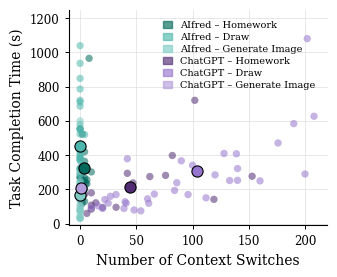

In [65]:
# ---------------------------------------------------------
# Colors
# ---------------------------------------------------------
COL_EX = '#00796b'
COL_CT = '#6a4c93'

# Task shades — AIfred
EX_HW = '#00695C'   # Homework
EX_DW = '#4DB6AC'   # Draw
EX_GI = '#80CBC4'   # Generate Image

# Task shades — ChatGPT
CT_HW = '#512B73'   # Homework
CT_DW = '#9575CD'   # Draw
CT_GI = '#B39DDB'   # Generate Image

# ---------------------------------------------------------
# Data
# ---------------------------------------------------------
ex_x = EX_quantitative_context_switching['nS']
ex_y = EX_quantitative_context_switching['task completion time']

ct_x = CT_quantitative_context_switching['nS']
ct_y = CT_quantitative_context_switching['task completion time']


# ---------------------------------------------------------
# Task labels / colors
#
# Data order:
#   Homework
#   Drawing
#   Drawing opposite
#   Generate Image
# ---------------------------------------------------------

n_ex_hw = len(ex_p['HW nS'])
n_ex_dw = len(ex_p['DW nS'])
n_ex_dw_opp = len(ct_p['DW opposite nS'])
n_ex_gi = len(ex_p['GI nS'])

n_ct_hw = len(ct_p['HW nS'])
n_ct_dw = len(ct_p['DW nS'])
n_ct_dw_opp = len(ex_p['DW opposite nS'])
n_ct_gi = len(ct_p['GI nS'])


# AIfred
ex_task_colors = (
    [EX_HW] * n_ex_hw +
    [EX_DW] * n_ex_dw +
    [EX_DW] * n_ex_dw_opp +
    [EX_GI] * n_ex_gi
)

# ChatGPT
ct_task_colors = (
    [CT_HW] * n_ct_hw +
    [CT_DW] * n_ct_dw +
    [CT_DW] * n_ct_dw_opp +
    [CT_GI] * n_ct_gi
)


# ---------------------------------------------------------
# Means by condition and task
# ---------------------------------------------------------

# =========================
# AIfred
# =========================

# Homework
ex_hw_x = ex_x.iloc[:n_ex_hw]
ex_hw_y = ex_y.iloc[:n_ex_hw]

# Draw + Draw opposite
ex_draw_x = ex_x.iloc[n_ex_hw:n_ex_hw + n_ex_dw + n_ex_dw_opp]
ex_draw_y = ex_y.iloc[n_ex_hw:n_ex_hw + n_ex_dw + n_ex_dw_opp]

# Generate Image
ex_gi_start = n_ex_hw + n_ex_dw + n_ex_dw_opp
ex_gi_x = ex_x.iloc[ex_gi_start:]
ex_gi_y = ex_y.iloc[ex_gi_start:]


# =========================
# ChatGPT
# =========================

# Homework
ct_hw_x = ct_x.iloc[:n_ct_hw]
ct_hw_y = ct_y.iloc[:n_ct_hw]

# Draw + Draw opposite
ct_draw_x = ct_x.iloc[n_ct_hw:n_ct_hw + n_ct_dw + n_ct_dw_opp]
ct_draw_y = ct_y.iloc[n_ct_hw:n_ct_hw + n_ct_dw + n_ct_dw_opp]

# Generate Image
ct_gi_start = n_ct_hw + n_ct_dw + n_ct_dw_opp
ct_gi_x = ct_x.iloc[ct_gi_start:]
ct_gi_y = ct_y.iloc[ct_gi_start:]


# ---------------------------------------------------------
# Mean values
# ---------------------------------------------------------

ex_hw_mean_x = ex_hw_x.mean()
ex_hw_mean_y = ex_hw_y.mean()

ex_draw_mean_x = ex_draw_x.mean()
ex_draw_mean_y = ex_draw_y.mean()

ex_gi_mean_x = ex_gi_x.mean()
ex_gi_mean_y = ex_gi_y.mean()

ct_hw_mean_x = ct_hw_x.mean()
ct_hw_mean_y = ct_hw_y.mean()

ct_draw_mean_x = ct_draw_x.mean()
ct_draw_mean_y = ct_draw_y.mean()

ct_gi_mean_x = ct_gi_x.mean()
ct_gi_mean_y = ct_gi_y.mean()


# ---------------------------------------------------------
# Figure
# ---------------------------------------------------------
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5,
    'legend.fontsize': 8
})

fig, ax = plt.subplots(figsize=(3.35, 2.75))


# ---------------------------------------------------------
# Individual observations
# ---------------------------------------------------------

# ChatGPT
ax.scatter(
    ct_x,
    ct_y,
    s=28,
    c=ct_task_colors,
    alpha=0.55,
    edgecolors='none',
    zorder=2
)

# AIfred
ax.scatter(
    ex_x,
    ex_y,
    s=28,
    c=ex_task_colors,
    alpha=0.55,
    edgecolors='none',
    zorder=2
)


# ---------------------------------------------------------
# Mean markers by condition and task
# ---------------------------------------------------------

mean_marker_size = 65

# AIfred – Homework
ax.scatter(
    ex_hw_mean_x, ex_hw_mean_y,
    s=mean_marker_size,
    color=EX_HW,
    edgecolors='black',
    linewidth=0.8,
    marker='o',
    zorder=5
)

# AIfred – Draw
ax.scatter(
    ex_draw_mean_x, ex_draw_mean_y,
    s=mean_marker_size,
    color=EX_DW,
    edgecolors='black',
    linewidth=0.8,
    marker='o',
    zorder=5
)

# AIfred – Generate Image
ax.scatter(
    ex_gi_mean_x, ex_gi_mean_y,
    s=mean_marker_size,
    color=EX_GI,
    edgecolors='black',
    linewidth=0.8,
    marker='o',
    zorder=5
)

# ChatGPT – Homework
ax.scatter(
    ct_hw_mean_x, ct_hw_mean_y,
    s=mean_marker_size,
    color=CT_HW,
    edgecolors='black',
    linewidth=0.8,
    marker='o',
    zorder=5
)

# ChatGPT – Draw
ax.scatter(
    ct_draw_mean_x, ct_draw_mean_y,
    s=mean_marker_size,
    color=CT_DW,
    edgecolors='black',
    linewidth=0.8,
    marker='o',
    zorder=5
)

# ChatGPT – Generate Image
ax.scatter(
    ct_gi_mean_x, ct_gi_mean_y,
    s=mean_marker_size,
    color=CT_GI,
    edgecolors='black',
    linewidth=0.8,
    marker='o',
    zorder=5
)

#ax.annotate(
#    f'$\\frac{{{ct_mean_y:.1f}s}}{{{ct_mean_x:.1f}\\ switches}}'
#    f'\\ =\\ {ct_sps:.1f}s/switch$',
#    (ct_mean_x, ct_mean_y),
#    xytext=(70, -25),
#    textcoords='offset points',
#    fontsize=10,
#    color='#000000',
#    ha='center',
#    va='bottom'
#)
#
#ax.annotate(
#    f'$\\frac{{{ex_mean_y:.1f}s}}{{{ex_mean_x:.1f}\\ switches}}'
#    f'\\ =\\ {ex_sps:.1f}s/switch$',
#    (ex_mean_x, ex_mean_y),
#    xytext=(70, 10),
#    textcoords='offset points',
#    fontsize=10,
#    color='#000000',
#    ha='center',
#    va='bottom'
#)
#ax.annotate(
#    f'({ex_mean_x:.1f}, {ex_mean_y:.0f} s)',
#    (ex_mean_x, ex_mean_y),
#    xytext=(5, 5),
#    textcoords='offset points',
#    fontsize=8.5,
#    color='#000000',#COL_EX,
#    #fontweight='bold',
#    ha='left',
#    va='bottom'
#)
#
#ax.annotate(
#    f'({ct_mean_x:.1f}, {ct_mean_y:.0f} s)',
#    (ct_mean_x, ct_mean_y),
#    xytext=(0, -14),
#    textcoords='offset points',
#    fontsize=8.5,
#    color='#000000',#COL_CT,
#    #fontweight='bold',
#    ha='left',
#    va='top'
#)

# ---------------------------------------------------------
# Axis labels
# ---------------------------------------------------------
ax.set_xlabel('Number of Context Switches')
ax.set_ylabel('Task Completion Time (s)')

# ---------------------------------------------------------
# Axis limits
# ---------------------------------------------------------
ax.set_xlim(-10, 220)
ax.set_ylim(-10, 1250)

# ---------------------------------------------------------
# Grid / axes styling
# ---------------------------------------------------------
ax.grid(
    True,
    axis='both',
    color='#D8D8D8',
    linewidth=0.6,
    alpha=0.7
)

ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

ax.tick_params(
    width=0.7,
    length=3
)


# ---------------------------------------------------------
# Legend
# ---------------------------------------------------------

legend_handles = [

    # AIfred
    Patch(
        facecolor=EX_HW,
        edgecolor=EX_HW,
        alpha=0.65,
        label='AIfred – Homework'
    ),
    Patch(
        facecolor=EX_DW,
        edgecolor=EX_DW,
        alpha=0.65,
        label='AIfred – Draw'
    ),
    Patch(
        facecolor=EX_GI,
        edgecolor=EX_GI,
        alpha=0.65,
        label='AIfred – Generate Image'
    ),

    # ChatGPT
    Patch(
        facecolor=CT_HW,
        edgecolor=CT_HW,
        alpha=0.65,
        label='ChatGPT – Homework'
    ),
    Patch(
        facecolor=CT_DW,
        edgecolor=CT_DW,
        alpha=0.65,
        label='ChatGPT – Draw'
    ),
    Patch(
        facecolor=CT_GI,
        edgecolor=CT_GI,
        alpha=0.65,
        label='ChatGPT – Generate Image'
    )
]

ax.legend(
    handles=legend_handles,
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98),
    fontsize=7,
    frameon=False,
    handlelength=1.0,
    handleheight=0.8,
    borderpad=0.2,
    labelspacing=0.3
)

# ---------------------------------------------------------
# Layout
# ---------------------------------------------------------
plt.tight_layout(pad=0.7)

# Save the figure as an SVG file
#plt.savefig('/content/drive/MyDrive/AIfred/ICRA/DataAnalysis/output_graphs/quantitative_context_switching.svg', format='svg', bbox_inches='tight')

plt.show()

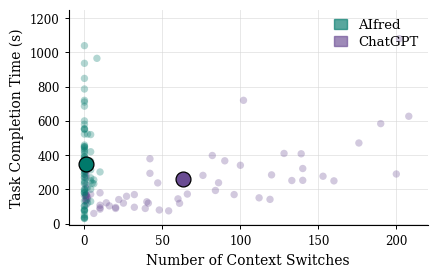

In [66]:
# ---------------------------------------------------------
# Colors
# ---------------------------------------------------------
COL_EX = '#00796b'   # AIfred
COL_CT = '#6a4c93'   # ChatGPT

# ---------------------------------------------------------
# Data
# ---------------------------------------------------------
ex_x = EX_quantitative_context_switching['nS']
ex_y = EX_quantitative_context_switching['task completion time']

ct_x = CT_quantitative_context_switching['nS']
ct_y = CT_quantitative_context_switching['task completion time']


# ---------------------------------------------------------
# Overall means
# ---------------------------------------------------------

ex_mean_x = ex_x.mean()
ex_mean_y = ex_y.mean()

ct_mean_x = ct_x.mean()
ct_mean_y = ct_y.mean()

# ---------------------------------------------------------
# Figure
# ---------------------------------------------------------
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5,
    'legend.fontsize': 8
})

fig, ax = plt.subplots(figsize=(4.35, 2.75))


# ---------------------------------------------------------
# Individual observations
# ---------------------------------------------------------

# ChatGPT
ax.scatter(
    ct_x,
    ct_y,
    s=28,
    color=COL_CT,
    alpha=0.3,
    edgecolors='none',
    zorder=2
)

# AIfred
ax.scatter(
    ex_x,
    ex_y,
    s=28,
    color=COL_EX,
    alpha=0.3,
    edgecolors='none',
    zorder=2
)

# ---------------------------------------------------------
# Overall mean markers
# ---------------------------------------------------------

mean_marker_size = 115

# ChatGPT mean
ax.scatter(
    ct_mean_x,
    ct_mean_y,
    s=mean_marker_size,
    color=COL_CT,
    edgecolors='black',
    linewidth=0.9,
    marker='o',
    zorder=5
)

# AIfred mean
ax.scatter(
    ex_mean_x,
    ex_mean_y,
    s=mean_marker_size,
    color=COL_EX,
    edgecolors='black',
    linewidth=0.9,
    marker='o',
    zorder=5
)

#ax.annotate(
#    f'$\\frac{{{ct_mean_y:.1f}s}}{{{ct_mean_x:.1f}\\ switches}}'
#    f'\\ =\\ {ct_sps:.1f}s/switch$',
#    (ct_mean_x, ct_mean_y),
#    xytext=(70, -25),
#    textcoords='offset points',
#    fontsize=10,
#    color='#000000',
#    ha='center',
#    va='bottom'
#)
#
#ax.annotate(
#    f'$\\frac{{{ex_mean_y:.1f}s}}{{{ex_mean_x:.1f}\\ switches}}'
#    f'\\ =\\ {ex_sps:.1f}s/switch$',
#    (ex_mean_x, ex_mean_y),
#    xytext=(70, 10),
#    textcoords='offset points',
#    fontsize=10,
#    color='#000000',
#    ha='center',
#    va='bottom'
#)
#ax.annotate(
#    f'({ex_mean_x:.1f}, {ex_mean_y:.0f} s)',
#    (ex_mean_x, ex_mean_y),
#    xytext=(5, 5),
#    textcoords='offset points',
#    fontsize=8.5,
#    color='#000000',#COL_EX,
#    #fontweight='bold',
#    ha='left',
#    va='bottom'
#)
#
#ax.annotate(
#    f'({ct_mean_x:.1f}, {ct_mean_y:.0f} s)',
#    (ct_mean_x, ct_mean_y),
#    xytext=(0, -14),
#    textcoords='offset points',
#    fontsize=8.5,
#    color='#000000',#COL_CT,
#    #fontweight='bold',
#    ha='left',
#    va='top'
#)

# ---------------------------------------------------------
# Axis labels
# ---------------------------------------------------------
ax.set_xlabel('Number of Context Switches')
ax.set_ylabel('Task Completion Time (s)')

# ---------------------------------------------------------
# Axis limits
# ---------------------------------------------------------
ax.set_xlim(-10, 220)
ax.set_ylim(-10, 1250)

# ---------------------------------------------------------
# Grid / axes styling
# ---------------------------------------------------------
ax.grid(
    True,
    axis='both',
    color='#D8D8D8',
    linewidth=0.6,
    alpha=0.7
)

ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

ax.tick_params(
    width=0.7,
    length=3
)


# =========================================================
# Legend
# =========================================================

legend_handles = [
    Patch(
        facecolor=COL_EX,
        edgecolor=COL_EX,
        alpha=0.65,
        label='AIfred'
    ),
    Patch(
        facecolor=COL_CT,
        edgecolor=COL_CT,
        alpha=0.65,
        label='ChatGPT'
    )
]

ax.legend(
    handles=legend_handles,
    loc='upper right',
    fontsize=9.5,
    frameon=False,
    handlelength=1.0,
    handleheight=0.8,
    borderpad=0.2,
    labelspacing=0.3
)


# ---------------------------------------------------------
# Layout
# ---------------------------------------------------------
plt.tight_layout(pad=0.7)

# Save the figure as an SVG file
plt.savefig('/content/drive/MyDrive/AIfred/ICRA/DataAnalysis/output_graphs/quantitative_context_switching.svg', format='svg', bbox_inches='tight')

plt.show()

In [67]:
import numpy as np
from scipy import stats

# =========================================================
# MEAN NUMBER OF CONTEXT SWITCHES (nS)
# =========================================================
ex_ns = EX_quantitative_context_switching['nS'].dropna()
ct_ns = CT_quantitative_context_switching['nS'].dropna()

# Descriptive statistics
ex_ns_mean = ex_ns.mean()
ex_ns_sd = ex_ns.std()
ct_ns_mean = ct_ns.mean()
ct_ns_sd = ct_ns.std()

# Welch's t-test
t_ns, p_ns = stats.ttest_ind(ex_ns, ct_ns, equal_var=False)

# Percentage difference
pct_diff_ns = ((ex_ns_mean - ct_ns_mean) / ct_ns_mean) * 100

print("===========================================================")
print("MEAN NUMBER OF CONTEXT SWITCHES")
print("===========================================================")
print(f"AIfred:  M = {ex_ns_mean:.2f}, SD = {ex_ns_sd:.2f}, N = {len(ex_ns)}")
print(f"ChatGPT: M = {ct_ns_mean:.2f}, SD = {ct_ns_sd:.2f}, N = {len(ct_ns)}")
print(f"Welch's t-test: t = {t_ns:.3f}, p = {p_ns:.5f}")
print(f"Percentage Difference (AIfred vs. ChatGPT): {pct_diff_ns:+.1f}%")


# =========================================================
# MEAN SECONDS PER SWITCH
# =========================================================
ex_sps = EX_quantitative_context_switching['seconds x switch'].dropna()
ct_sps = CT_quantitative_context_switching['seconds x switch'].dropna()

# Descriptive statistics
ex_sps_mean = ex_sps.mean()
ex_sps_sd = ex_sps.std()
ct_sps_mean = ct_sps.mean()
ct_sps_sd = ct_sps.std()

# Welch's t-test
t_sps, p_sps = stats.ttest_ind(ex_sps, ct_sps, equal_var=False)

# Percentage difference
pct_diff_sps = ((ex_sps_mean - ct_sps_mean) / ct_sps_mean) * 100

print("\n===========================================================")
print("MEAN SECONDS PER SWITCH")
print("===========================================================")
print(f"AIfred:  M = {ex_sps_mean:.2f}, SD = {ex_sps_sd:.2f}, N = {len(ex_sps)}")
print(f"ChatGPT: M = {ct_sps_mean:.2f}, SD = {ct_sps_sd:.2f}, N = {len(ct_sps)}")
print(f"Welch's t-test: t = {t_sps:.3f}, p = {p_sps:.5f}")
print(f"Percentage Difference (AIfred vs. ChatGPT): {pct_diff_sps:+.1f}%")

MEAN NUMBER OF CONTEXT SWITCHES
AIfred:  M = 1.01, SD = 2.15, N = 72
ChatGPT: M = 63.08, SD = 74.14, N = 72
Welch's t-test: t = -7.100, p = 0.00000
Percentage Difference (AIfred vs. ChatGPT): -98.4%

MEAN SECONDS PER SWITCH
AIfred:  M = 294.06, SD = 240.76, N = 72
ChatGPT: M = 57.83, SD = 95.55, N = 72
Welch's t-test: t = 7.739, p = 0.00000
Percentage Difference (AIfred vs. ChatGPT): +408.5%


In [68]:
from scipy import stats
import numpy as np

# ---------------------------------------------------------
# Task completion time
# ---------------------------------------------------------
ex_time = EX_quantitative_context_switching['task completion time'].dropna()
ct_time = CT_quantitative_context_switching['task completion time'].dropna()

# Descriptive statistics
ex_mean = ex_time.mean()
ct_mean = ct_time.mean()

ex_sd = ex_time.std()
ct_sd = ct_time.std()

# ---------------------------------------------------------
# Welch independent-samples t-test
# ---------------------------------------------------------
t_stat, p_value = stats.ttest_ind(
    ex_time,
    ct_time,
    equal_var=False
)

# ---------------------------------------------------------
# Percentage difference
# ---------------------------------------------------------
# How much faster ChatGPT is relative to AIfred
chat_faster = (ex_mean - ct_mean) / ex_mean * 100

# ---------------------------------------------------------
# Print results
# ---------------------------------------------------------
print("Task Completion Time")
print("--------------------")
print(f"AIfred:  M = {ex_mean:.1f} s, SD = {ex_sd:.1f}, N = {len(ex_time)}")
print(f"ChatGPT: M = {ct_mean:.1f} s, SD = {ct_sd:.1f}, N = {len(ct_time)}")

print("\nWelch's t-test")
print("--------------------")
print(f"t = {t_stat:.3f}")
print(f"p = {p_value:.5f}")

print("\nDifference")
print("--------------------")
print(f"Mean difference = {ex_mean - ct_mean:.1f} s")
print(f"ChatGPT is {chat_faster:.1f}% faster than AIfred")

Task Completion Time
--------------------
AIfred:  M = 349.5 s, SD = 231.0, N = 72
ChatGPT: M = 259.9 s, SD = 249.3, N = 72

Welch's t-test
--------------------
t = 2.237
p = 0.02688

Difference
--------------------
Mean difference = 89.6 s
ChatGPT is 25.6% faster than AIfred


In [69]:
EX_time_per_task = pd.DataFrame({
    'task completion time': pd.concat([
        ex_p['t HM'],
        ex_p['t GI'],
        ex_p['t DW'],
        ct_p['t DW opposite']
    ], ignore_index=True)
})

CT_time_per_task = pd.DataFrame({
    'task completion time': pd.concat([
        ct_p['t HM'],
        ct_p['t GI'],
        ct_p['t DW'],
        ex_p['t DW opposite']
    ], ignore_index=True)
})

# transform to seconds
EX_time_per_task['task completion time'] = (
    EX_time_per_task['task completion time']
    .apply(convert_min_sec_to_seconds)
)

CT_time_per_task['task completion time'] = (
    CT_time_per_task['task completion time']
    .apply(convert_min_sec_to_seconds)
)

# Print all interesting values (means, p-values, etc...)
from scipy import stats
import numpy as np

# ---------------------------------------------------------
# Clean data
# ---------------------------------------------------------

ex_time = EX_time_per_task['task completion time'].dropna()
ct_time = CT_time_per_task['task completion time'].dropna()


# ---------------------------------------------------------
# Descriptive statistics
# ---------------------------------------------------------

print("==============================================")
print("TASK COMPLETION TIME")
print("==============================================")

print(f"AIfred  : N = {len(ex_time)}, "
      f"Mean = {ex_time.mean():.2f} s, "
      f"SD = {ex_time.std():.2f} s, "
      f"Median = {ex_time.median():.2f} s, "
      f"Range = [{ex_time.min():.2f}, {ex_time.max():.2f}]")

print(f"ChatGPT : N = {len(ct_time)}, "
      f"Mean = {ct_time.mean():.2f} s, "
      f"SD = {ct_time.std():.2f} s, "
      f"Median = {ct_time.median():.2f} s, "
      f"Range = [{ct_time.min():.2f}, {ct_time.max():.2f}]")

print()


# ---------------------------------------------------------
# Welch's independent-samples t-test
# ---------------------------------------------------------

t_stat, p_value = stats.ttest_ind(
    ex_time,
    ct_time,
    equal_var=False
)

print("==============================================")
print("WELCH'S T-TEST")
print("==============================================")

print(f"t = {t_stat:.3f}")
print(f"p = {p_value:.6f}")


# ---------------------------------------------------------
# Cohen's d
# ---------------------------------------------------------

n_ex = len(ex_time)
n_ct = len(ct_time)

pooled_sd = np.sqrt(
    ((n_ex - 1) * ex_time.var(ddof=1) +
     (n_ct - 1) * ct_time.var(ddof=1))
    / (n_ex + n_ct - 2)
)

cohens_d = (
    (ex_time.mean() - ct_time.mean())
    / pooled_sd
)

print(f"Cohen's d = {cohens_d:.3f}")


# ---------------------------------------------------------
# Percentage difference
# ---------------------------------------------------------

percent_difference = (
    (ex_time.mean() - ct_time.mean())
    / ct_time.mean()
    * 100
)

print(f"AIfred vs. ChatGPT = {percent_difference:+.1f}%")

TASK COMPLETION TIME
AIfred  : N = 72, Mean = 349.49 s, SD = 231.02 s, Median = 307.00 s, Range = [30.00, 1039.00]
ChatGPT : N = 72, Mean = 259.89 s, SD = 249.34 s, Median = 172.50 s, Range = [60.00, 1816.00]

WELCH'S T-TEST
t = 2.237
p = 0.026879
Cohen's d = 0.373
AIfred vs. ChatGPT = +34.5%


In [70]:
import numpy as np
import pandas as pd
from scipy import stats


# =========================================================
# DATA
# =========================================================

EX_time_per_task = pd.DataFrame({
    'task': (
        ['Homework'] * len(ex_p['t HM']) +
        ['Image Generation'] * len(ex_p['t GI']) +
        ['Drawing'] * len(ex_p['t DW']) +
        ['Drawing'] * len(ct_p['t DW opposite'])
    ),

    'task completion time': pd.concat([
        ex_p['t HM'],
        ex_p['t GI'],
        ex_p['t DW'],
        ct_p['t DW opposite']
    ], ignore_index=True)
})


CT_time_per_task = pd.DataFrame({
    'task': (
        ['Homework'] * len(ct_p['t HM']) +
        ['Image Generation'] * len(ct_p['t GI']) +
        ['Drawing'] * len(ct_p['t DW']) +
        ['Drawing'] * len(ex_p['t DW opposite'])
    ),

    'task completion time': pd.concat([
        ct_p['t HM'],
        ct_p['t GI'],
        ct_p['t DW'],
        ex_p['t DW opposite']
    ], ignore_index=True)
})


# =========================================================
# CONVERT TO SECONDS
# =========================================================

EX_time_per_task['task completion time'] = (
    EX_time_per_task['task completion time']
    .apply(convert_min_sec_to_seconds)
)

CT_time_per_task['task completion time'] = (
    CT_time_per_task['task completion time']
    .apply(convert_min_sec_to_seconds)
)


# =========================================================
# OVERALL STATISTICS
# =========================================================

ex_time = EX_time_per_task['task completion time'].dropna()
ct_time = CT_time_per_task['task completion time'].dropna()

ex_mean = ex_time.mean()
ct_mean = ct_time.mean()

ex_sd = ex_time.std()
ct_sd = ct_time.std()

ex_median = ex_time.median()
ct_median = ct_time.median()

# Welch's t-test
t_stat, p_value = stats.ttest_ind(
    ex_time,
    ct_time,
    equal_var=False
)

# Cohen's d
pooled_sd = np.sqrt(
    ((len(ex_time) - 1) * ex_sd**2 +
     (len(ct_time) - 1) * ct_sd**2)
    /
    (len(ex_time) + len(ct_time) - 2)
)

cohens_d = (ex_mean - ct_mean) / pooled_sd

# Difference
mean_difference = ex_mean - ct_mean

# Percentage difference
percentage_difference = (
    (ex_mean - ct_mean) / ct_mean * 100
)


# =========================================================
# PRINT OVERALL RESULTS
# =========================================================

print("=" * 60)
print("OVERALL TASK COMPLETION TIME")
print("=" * 60)

print(f"AIfred:")
print(f"  N       = {len(ex_time)}")
print(f"  Mean    = {ex_mean:.2f} s")
print(f"  SD      = {ex_sd:.2f} s")
print(f"  Median  = {ex_median:.2f} s")

print(f"\nChatGPT:")
print(f"  N       = {len(ct_time)}")
print(f"  Mean    = {ct_mean:.2f} s")
print(f"  SD      = {ct_sd:.2f} s")
print(f"  Median  = {ct_median:.2f} s")

print("\nComparison:")
print(f"  Mean difference (AIfred - ChatGPT) = {mean_difference:.2f} s")
print(f"  Percentage difference              = {percentage_difference:+.1f}%")
print(f"  Welch t-statistic                  = {t_stat:.3f}")

if p_value < 0.001:
    print(f"  p-value                             < .001")
else:
    print(f"  p-value                             = {p_value:.3f}")

print(f"  Cohen's d                           = {cohens_d:.3f}")


# =========================================================
# PER-TASK STATISTICS
# =========================================================

def format_p(p):
    if p < 0.001:
        return "p < .001"
    return f"p = {p:.3f}"


print("\n\n")
print("=" * 60)
print("TASK-BY-TASK COMPLETION TIME")
print("=" * 60)

for task in ['Homework', 'Image Generation', 'Drawing']:

    ex_task = (
        EX_time_per_task[
            EX_time_per_task['task'] == task
        ]['task completion time']
        .dropna()
    )

    ct_task = (
        CT_time_per_task[
            CT_time_per_task['task'] == task
        ]['task completion time']
        .dropna()
    )

    # Welch t-test
    t, p = stats.ttest_ind(
        ex_task,
        ct_task,
        equal_var=False
    )

    # Cohen's d
    ex_sd_task = ex_task.std()
    ct_sd_task = ct_task.std()

    pooled_sd_task = np.sqrt(
        (
            (len(ex_task) - 1) * ex_sd_task**2 +
            (len(ct_task) - 1) * ct_sd_task**2
        )
        /
        (len(ex_task) + len(ct_task) - 2)
    )

    d = (
        ex_task.mean() - ct_task.mean()
    ) / pooled_sd_task

    # Percentage difference
    pct = (
        (ex_task.mean() - ct_task.mean())
        / ct_task.mean()
        * 100
    )

    print(f"\n--- {task} ---")

    print(
        f"AIfred:  "
        f"M = {ex_task.mean():.2f}s, "
        f"SD = {ex_task.std():.2f}s, "
        f"N = {len(ex_task)}"
    )

    print(
        f"ChatGPT: "
        f"M = {ct_task.mean():.2f}s, "
        f"SD = {ct_task.std():.2f}s, "
        f"N = {len(ct_task)}"
    )

    print(
        f"Difference: {ex_task.mean() - ct_task.mean():+.2f}s "
        f"({pct:+.1f}%)"
    )

    print(
        f"Welch's t = {t:.3f}, "
        f"{format_p(p)}, "
        f"Cohen's d = {d:.3f}"
    )

OVERALL TASK COMPLETION TIME
AIfred:
  N       = 72
  Mean    = 349.49 s
  SD      = 231.02 s
  Median  = 307.00 s

ChatGPT:
  N       = 72
  Mean    = 259.89 s
  SD      = 249.34 s
  Median  = 172.50 s

Comparison:
  Mean difference (AIfred - ChatGPT) = 89.60 s
  Percentage difference              = +34.5%
  Welch t-statistic                  = 2.237
  p-value                             = 0.027
  Cohen's d                           = 0.373



TASK-BY-TASK COMPLETION TIME

--- Homework ---
AIfred:  M = 327.11s, SD = 196.54s, N = 18
ChatGPT: M = 213.50s, SD = 156.02s, N = 18
Difference: +113.61s (+53.2%)
Welch's t = 1.921, p = 0.064, Cohen's d = 0.640

--- Image Generation ---
AIfred:  M = 167.06s, SD = 156.76s, N = 18
ChatGPT: M = 208.22s, SD = 74.35s, N = 18
Difference: -41.17s (-19.8%)
Welch's t = -1.007, p = 0.324, Cohen's d = -0.336

--- Drawing ---
AIfred:  M = 451.89s, SD = 222.28s, N = 36
ChatGPT: M = 308.92s, SD = 326.58s, N = 36
Difference: +142.97s (+46.3%)
Welch's t = 2.171

### <font color="green">Qualitative

**QID2_1**: I was able to maintain my attention on my physical work while using the system.

**QID2_2**: The system allowed me to access information without interrupting my concentration.

**QID2_3**: I could use the system without frequently shifting my attention away from my work.

**QID2_4**: The system helped me maintain a continuous workflow between receiving assistance and performing the task.


In [71]:
EX_percived_context_switching = ex_q[['QID2_1 (Perceived Context Switching)',
              'QID2_2 (Perceived Context Switching)',
              'QID2_3 (Perceived Context Switching)',
              'QID2_4 (Perceived Context Switching)']]

CT_percived_context_switching = ct_q[['QID2_1 (Perceived Context Switching)',
              'QID2_2 (Perceived Context Switching)',
              'QID2_3 (Perceived Context Switching)',
              'QID2_4 (Perceived Context Switching)']]

In [72]:
print('Experimental Condition Percived Context Switching:')
display(EX_percived_context_switching)

print('\nControl Condition Percived Context Switching:')
display(CT_percived_context_switching)

Experimental Condition Percived Context Switching:


,QID2_1 (Perceived Context Switching),QID2_2 (Perceived Context Switching),QID2_3 (Perceived Context Switching),QID2_4 (Perceived Context Switching)
0,5,5,4,4
1,5,5,5,5
2,3,5,4,4
3,5,5,5,5
4,4,5,3,4
5,5,5,5,5
6,5,5,5,5
7,5,2,3,4
8,5,5,5,5
9,5,5,4,5



Control Condition Percived Context Switching:


,QID2_1 (Perceived Context Switching),QID2_2 (Perceived Context Switching),QID2_3 (Perceived Context Switching),QID2_4 (Perceived Context Switching)
18,4,4,5,5
19,5,4,4,5
20,2,3,2,3
21,4,5,5,4
22,4,4,3,3
23,4,4,4,4
24,5,5,5,5
25,4,4,4,4
26,2,3,3,3
27,5,4,5,5


In [73]:
EX_percived_context_switching_avg = 6 - EX_percived_context_switching.mean(axis=1)
CT_percived_context_switching_avg = 6 - CT_percived_context_switching.mean(axis=1)

# Calculate mean and standard deviation for Experimental group
mean_ex = EX_percived_context_switching_avg.mean()
std_ex = EX_percived_context_switching_avg.std()

# Calculate mean and standard deviation for Control group
mean_ct = CT_percived_context_switching_avg.mean()
std_ct = CT_percived_context_switching_avg.std()

# Perform independent t-test
t_statistic, p_value = stats.ttest_ind(EX_percived_context_switching_avg, CT_percived_context_switching_avg, equal_var=False) # Welch's t-test assuming unequal variances

print(f"Experimental Group (Perceived Context Switching):\n  Mean: {mean_ex:.2f}\n  Standard Deviation: {std_ex:.2f}")
print(f"\nControl Group (Perceived Context Switching):\n  Mean: {mean_ct:.2f}\n  Standard Deviation: {std_ct:.2f}")
print(f"\nP-value (Experimental vs. Control): {p_value:.3f}")

Experimental Group (Perceived Context Switching):
  Mean: 1.29
  Standard Deviation: 0.44

Control Group (Perceived Context Switching):
  Mean: 1.74
  Standard Deviation: 0.74

P-value (Experimental vs. Control): 0.037


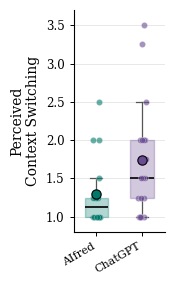

In [74]:
# ---------------------------------------------------------
# Colors
# ---------------------------------------------------------
COL_EX = '#00796b'
COL_CT = '#6a4c93'

# ---------------------------------------------------------
# Data
# ---------------------------------------------------------
ex_data = EX_percived_context_switching_avg.dropna()
ct_data = CT_percived_context_switching_avg.dropna()

# ---------------------------------------------------------
# Figure
# ---------------------------------------------------------
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5
})

fig, ax = plt.subplots(figsize=(1.65, 2.75))

# ---------------------------------------------------------
# Box plots
# ---------------------------------------------------------
bp = ax.boxplot(
    [ex_data, ct_data],
    positions=[1, 2],
    widths=0.52,
    patch_artist=True,
    showfliers=False,

    medianprops=dict(
        color='black',
        linewidth=1.2
    ),

    whiskerprops=dict(
        color='#555555',
        linewidth=0.9
    ),

    capprops=dict(
        color='#555555',
        linewidth=0.9
    ),

    boxprops=dict(
        linewidth=1.0
    )
)

bp['boxes'][0].set_facecolor(COL_EX)
bp['boxes'][0].set_alpha(0.30)
bp['boxes'][0].set_edgecolor(COL_EX)

bp['boxes'][1].set_facecolor(COL_CT)
bp['boxes'][1].set_alpha(0.30)
bp['boxes'][1].set_edgecolor(COL_CT)

# ---------------------------------------------------------
# Individual observations
# ---------------------------------------------------------
rng = np.random.default_rng(42)

ax.scatter(
    1 + rng.uniform(-0.09, 0.09, len(ex_data)),
    ex_data,
    s=20,
    color=COL_EX,
    alpha=0.60,
    edgecolors='white',
    linewidth=0.3,
    zorder=4
)

ax.scatter(
    2 + rng.uniform(-0.09, 0.09, len(ct_data)),
    ct_data,
    s=20,
    color=COL_CT,
    alpha=0.60,
    edgecolors='white',
    linewidth=0.3,
    zorder=4
)

# ---------------------------------------------------------
# Mean markers
# ---------------------------------------------------------
ax.scatter(
    1,
    ex_data.mean(),
    s=45,
    color=COL_EX,
    edgecolors='black',
    linewidth=0.8,
    zorder=6
)

ax.scatter(
    2,
    ct_data.mean(),
    s=45,
    color=COL_CT,
    edgecolors='black',
    linewidth=0.8,
    zorder=6
)

# ---------------------------------------------------------
# Mean labels
# ---------------------------------------------------------
#ax.text(
#    1,
#    ex_data.mean() + 0.08,
#    f'{ex_data.mean():.2f}',
#    ha='center',
#    va='bottom',
#    fontsize=8.5
#)
#
#ax.text(
#    2,
#    ct_data.mean() + 0.03, # Adjusted y-offset to place below the dot
#    f'{ct_data.mean():.2f}',
#    ha='center',
#    va='bottom',
#    fontsize=8.5
#)
# ---------------------------------------------------------
# Axes
# ---------------------------------------------------------
ax.set_xticks([1, 2])
ax.set_xticklabels(
    ['AIfred', 'ChatGPT'],
    fontsize=8
)
plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha='right'
)

ax.set_ylabel('Perceived\nContext Switching')

# IMPORTANT:
# Zoom to the actual observed range
all_data = np.concatenate([ex_data.values, ct_data.values])

y_min = np.floor((all_data.min() - 0.15) * 10) / 10
y_max = np.ceil((all_data.max() + 0.20) * 10) / 10

ax.set_ylim(y_min, y_max)

# Nice ticks around the observed values
ax.yaxis.set_major_locator(
    plt.MultipleLocator(0.5)
)

# ---------------------------------------------------------
# Grid
# ---------------------------------------------------------
ax.grid(
    axis='y',
    color='#D8D8D8',
    linewidth=0.6,
    alpha=0.7
)

ax.set_axisbelow(True)

# ---------------------------------------------------------
# Spines
# ---------------------------------------------------------
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

ax.tick_params(
    width=0.7,
    length=3
)

plt.tight_layout(pad=0.4)
# Save the figure as an SVG file
#plt.savefig('/content/drive/MyDrive/AIfred/ICRA/DataAnalysis/output_graphs/qualitative_context_switching.svg', format='svg', bbox_inches='tight')

plt.show()

# **Homework**

### <font color="green">Gemini Variance

In [106]:
# =========================================================
# Gemini agent grading consistency
# =========================================================

# Columns containing the 4 Gemini grades
HW_HELP_COLS = [
    'HW grade 1',
    'HW grade 2',
    'HW grade 3',
    'HW grade 4'
]

HW_NO_HELP_COLS = [
    'HW grade no help 1',
    'HW grade no help 2',
    'HW grade no help 3',
    'HW grade no help 4'
]


# =========================================================
# Function to calculate agreement statistics
# =========================================================

def calculate_agent_consistency(df, group_name):

    # -----------------------------------------------------
    # Extract the four agent scores
    # -----------------------------------------------------
    help_scores = df[HW_HELP_COLS]
    no_help_scores = df[HW_NO_HELP_COLS]

    # -----------------------------------------------------
    # Per-participant variance
    #
    # ddof=1 = sample variance
    # This is the standard statistical estimate of variance
    # from the four agents.
    # -----------------------------------------------------
    help_variance = help_scores.var(axis=1, ddof=1)
    no_help_variance = no_help_scores.var(axis=1, ddof=1)

    # -----------------------------------------------------
    # Per-participant standard deviation
    # -----------------------------------------------------
    help_sd = help_scores.std(axis=1, ddof=1)
    no_help_sd = no_help_scores.std(axis=1, ddof=1)

    # -----------------------------------------------------
    # Per-participant range
    # Maximum agent score - minimum agent score
    # -----------------------------------------------------
    help_range = help_scores.max(axis=1) - help_scores.min(axis=1)
    no_help_range = no_help_scores.max(axis=1) - no_help_scores.min(axis=1)

    # -----------------------------------------------------
    # Per-participant mean absolute deviation from
    # the four-agent mean
    # -----------------------------------------------------
    help_mean = help_scores.mean(axis=1)
    no_help_mean = no_help_scores.mean(axis=1)

    help_mad = help_scores.sub(help_mean, axis=0).abs().mean(axis=1)
    no_help_mad = no_help_scores.sub(no_help_mean, axis=0).abs().mean(axis=1)

    # -----------------------------------------------------
    # Summary
    # -----------------------------------------------------
    results = pd.DataFrame({
        'Condition': [
            'With Assistance',
            'Without Assistance'
        ],

        'Mean Variance': [
            help_variance.mean(),
            no_help_variance.mean()
        ],

        'Median Variance': [
            help_variance.median(),
            no_help_variance.median()
        ],

        'Mean SD': [
            help_sd.mean(),
            no_help_sd.mean()
        ],

        'Median SD': [
            help_sd.median(),
            no_help_sd.median()
        ],

        'Mean Range': [
            help_range.mean(),
            no_help_range.mean()
        ],

        'Maximum Range': [
            help_range.max(),
            no_help_range.max()
        ],

        'Mean Absolute Deviation': [
            help_mad.mean(),
            no_help_mad.mean()
        ]
    })

    print(f"\n{'='*60}")
    print(f"{group_name} — Gemini Agent Consistency")
    print(f"{'='*60}")

    display(results.round(4))

    # -----------------------------------------------------
    # Detailed participant-level results
    # -----------------------------------------------------
    participant_results = pd.DataFrame({
        'HW Variance': help_variance,
        'HW SD': help_sd,
        'HW Range': help_range,
        'HW MAD': help_mad,

        'HW No Help Variance': no_help_variance,
        'HW No Help SD': no_help_sd,
        'HW No Help Range': no_help_range,
        'HW No Help MAD': no_help_mad
    })

    return results, participant_results


# =========================================================
# Run for AIfred
# =========================================================

EX_agent_summary, EX_agent_participant = calculate_agent_consistency(
    ex_p,
    'AIfred'
)


# =========================================================
# Run for ChatGPT
# =========================================================

CT_agent_summary, CT_agent_participant = calculate_agent_consistency(
    ct_p,
    'ChatGPT'
)



# =========================================================
# Overall inter-agent SD
# =========================================================

overall_agent_sd = pd.concat([
    EX_agent_participant['HW SD'],
    EX_agent_participant['HW No Help SD'],
    CT_agent_participant['HW SD'],
    CT_agent_participant['HW No Help SD']
]).mean()

print("\n" + "="*60)
print("OVERALL GEMINI AGENT CONSISTENCY")
print("="*60)
print(f"Overall mean inter-agent SD: {overall_agent_sd:.3f} points")


AIfred — Gemini Agent Consistency


,Condition,Mean Variance,Median Variance,Mean SD,Median SD,Mean Range,Maximum Range,Mean Absolute Deviation
0,With Assistance,0.3215,0.1250,0.4174,0.3500,0.9278,2.8,0.3139
1,Without Assistance,0.1477,0.0725,0.2710,0.2686,0.5556,1.7,0.2069



ChatGPT — Gemini Agent Consistency


,Condition,Mean Variance,Median Variance,Mean SD,Median SD,Mean Range,Maximum Range,Mean Absolute Deviation
0,With Assistance,1.4164,0.09,0.6904,0.3,1.4889,7.9,0.5292
1,Without Assistance,1.3584,0.16,0.7308,0.4,1.5833,7.9,0.5514



OVERALL GEMINI AGENT CONSISTENCY
Overall mean inter-agent SD: 0.527 points


### <font color="green">Quantitative


In [76]:
EX_math_grades = pd.DataFrame({
    'Math Grade with Help': ex_p['HW grade'],
    'Math Grade without Help': ex_p['HW grade no help']
})

CT_math_grades = pd.DataFrame({
    'Math Grade with Help': ct_p['HW grade'],
    'Math Grade without Help': ct_p['HW grade no help']
})

display(EX_math_grades)
display(CT_math_grades)

,Math Grade with Help,Math Grade without Help
0,6.500,8.175
1,7.050,7.650
2,6.025,8.850
3,8.700,8.850
4,7.925,8.475
5,1.350,2.100
6,3.250,2.425
7,6.950,8.900
8,8.900,8.900
9,8.750,8.325


,Math Grade with Help,Math Grade without Help
18,7.650,3.675
19,6.325,5.225
20,7.650,3.425
21,8.900,8.900
22,7.650,6.100
23,7.350,2.700
24,4.400,2.100
25,8.475,6.775
26,6.675,1.900
27,5.925,5.925


AIfred
  With help:    6.70
  Without help: 6.98
  Difference:   +0.27
  Transfer:     +4.1%

ChatGPT
  With help:    7.28
  Without help: 4.36
  Difference:   -2.92
  Transfer:     -40.1%


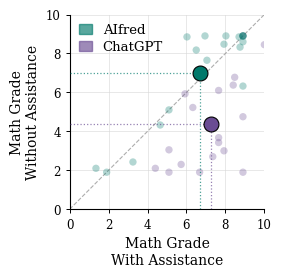

In [77]:
# =========================================================
# Colors
# =========================================================
COL_EX = '#00796b'
COL_CT = '#6a4c93'
COL_GRID = '#D8D8D8'

# =========================================================
# Data
# =========================================================

# Remove participants with missing values
ex_data = EX_math_grades.dropna(
    subset=['Math Grade with Help', 'Math Grade without Help']
)

ct_data = CT_math_grades.dropna(
    subset=['Math Grade with Help', 'Math Grade without Help']
)

# X = grade with help
# Y = grade without help
ex_x = ex_data['Math Grade with Help']
ex_y = ex_data['Math Grade without Help']

ct_x = ct_data['Math Grade with Help']
ct_y = ct_data['Math Grade without Help']


# =========================================================
# Cluster centers
# =========================================================

ex_mean_x = ex_x.mean()
ex_mean_y = ex_y.mean()

ct_mean_x = ct_x.mean()
ct_mean_y = ct_y.mean()


# =========================================================
# Short-term learning transfer
# =========================================================
# Relative change after assistance is removed:
#
# (without help - with help) / with help * 100
#
# Positive = performance increased without assistance
# Negative = performance decreased without assistance

ex_transfer = ((ex_y - ex_x) / ex_x.replace(0, np.nan)) * 100
ct_transfer = ((ct_y - ct_x) / ct_x.replace(0, np.nan)) * 100

# Mean participant-level transfer
ex_transfer_mean = ex_transfer.mean()
ct_transfer_mean = ct_transfer.mean()


# =========================================================
# Cluster-level transfer
# =========================================================
# This is what we display next to the cluster center.
#
# Using the cluster means gives:
# (mean without help - mean with help) / mean with help

ex_cluster_transfer = (
    (ex_mean_y - ex_mean_x) / ex_mean_x
) * 100

ct_cluster_transfer = (
    (ct_mean_y - ct_mean_x) / ct_mean_x
) * 100


# =========================================================
# Print statistics
# =========================================================

print("AIfred")
print(f"  With help:    {ex_mean_x:.2f}")
print(f"  Without help: {ex_mean_y:.2f}")
print(f"  Difference:   {ex_mean_y - ex_mean_x:+.2f}")
print(f"  Transfer:     {ex_cluster_transfer:+.1f}%")

print("\nChatGPT")
print(f"  With help:    {ct_mean_x:.2f}")
print(f"  Without help: {ct_mean_y:.2f}")
print(f"  Difference:   {ct_mean_y - ct_mean_x:+.2f}")
print(f"  Transfer:     {ct_cluster_transfer:+.1f}%")


# =========================================================
# Figure
# =========================================================

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5,
    'legend.fontsize': 8
})

fig, ax = plt.subplots(figsize=(3.35, 2.75))


# =========================================================
# Individual observations
# =========================================================

ax.scatter(
    ct_x,
    ct_y,
    s=28,
    color=COL_CT,
    alpha=0.3,
    edgecolors='none',
    label='ChatGPT',
    zorder=2
)

ax.scatter(
    ex_x,
    ex_y,
    s=28,
    color=COL_EX,
    alpha=0.3,
    edgecolors='none',
    label='AIfred',
    zorder=2
)


# =========================================================
# No-change reference line
# =========================================================

ax.plot(
    [0, 10],
    [0, 10],
    linestyle='--',
    color='#999999',
    linewidth=0.8,
    alpha=0.8,
    zorder=1
)


# =========================================================
# Mean / cluster centers
# =========================================================

ax.scatter(
    ct_mean_x,
    ct_mean_y,
    s=115,
    color=COL_CT,
    edgecolors='black',
    linewidth=0.8,
    marker='o',
    zorder=5
)

ax.scatter(
    ex_mean_x,
    ex_mean_y,
    s=115,
    color=COL_EX,
    edgecolors='black',
    linewidth=0.8,
    marker='o',
    zorder=5
)

# =========================================================
# Mean projections to axes
# =========================================================

# ChatGPT
ax.plot(
    [ct_mean_x, ct_mean_x],
    [0, ct_mean_y],
    linestyle=':',
    color=COL_CT,
    linewidth=0.9,
    alpha=0.7,
    zorder=3
)

ax.plot(
    [0, ct_mean_x],
    [ct_mean_y, ct_mean_y],
    linestyle=':',
    color=COL_CT,
    linewidth=0.9,
    alpha=0.7,
    zorder=3
)

# AIfred
ax.plot(
    [ex_mean_x, ex_mean_x],
    [0, ex_mean_y],
    linestyle=':',
    color=COL_EX,
    linewidth=0.9,
    alpha=0.7,
    zorder=3
)

ax.plot(
    [0, ex_mean_x],
    [ex_mean_y, ex_mean_y],
    linestyle=':',
    color=COL_EX,
    linewidth=0.9,
    alpha=0.7,
    zorder=3
)
# =========================================================
# Transfer labels
# =========================================================
#
#ax.annotate(
#    f'{ct_cluster_transfer:+.1f}%',
#    (ct_mean_x, ct_mean_y),
#    xytext=(0, -12),
#    textcoords='offset points',
#    fontsize=11,
#    #fontweight='bold',
#    color='#000000',#COL_CT,
#    ha='center',
#    va='top'
#)
#
#ax.annotate(
#    f'{ex_cluster_transfer:+.1f}%',
#    (ex_mean_x, ex_mean_y),
#    xytext=(0, -13),
#    textcoords='offset points',
#    fontsize=11,
#    #fontweight='bold',
#    color='#000000',#COL_EX,
#    ha='center',
#    va='top'
#)


# =========================================================
# Axis labels
# =========================================================

ax.set_xlabel('Math Grade\nWith Assistance')
ax.set_ylabel('Math Grade\nWithout Assistance')


# =========================================================
# Axis limits
# =========================================================

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)


# =========================================================
# Equal aspect ratio
# =========================================================

ax.set_aspect('equal', adjustable='box')


# =========================================================
# Grid
# =========================================================

ax.grid(
    True,
    axis='both',
    color=COL_GRID,
    linewidth=0.6,
    alpha=0.7
)

ax.set_axisbelow(True)


# =========================================================
# Spines
# =========================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

ax.tick_params(
    width=0.7,
    length=3
)


# =========================================================
# Legend
# =========================================================

legend_handles = [
    Patch(
        facecolor=COL_EX,
        edgecolor=COL_EX,
        alpha=0.65,
        label='AIfred'
    ),
    Patch(
        facecolor=COL_CT,
        edgecolor=COL_CT,
        alpha=0.65,
        label='ChatGPT'
    )
]

ax.legend(
    handles=legend_handles,
    loc='upper left',
    fontsize=9.5,
    frameon=False,
    handlelength=1.0,
    handleheight=0.8,
    borderpad=0.2,
    labelspacing=0.3
)


# =========================================================
# Layout
# =========================================================

plt.tight_layout(pad=0.7)
# Save the figure as an SVG file
plt.savefig('/content/drive/MyDrive/AIfred/ICRA/DataAnalysis/output_graphs/homework_quantitative.svg', format='svg', bbox_inches='tight')

plt.show()

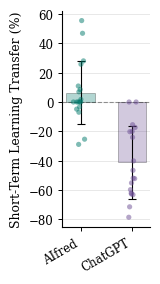

In [78]:
# =========================================================
# Colors (reuse same palette)
# =========================================================
COL_EX = '#00796b'
COL_CT = '#6a4c93'
COL_GRID = '#D8D8D8'

# =========================================================
# Data (reuses ex_transfer, ct_transfer from the previous script)
# =========================================================

ex_transfer_clean = ex_transfer.dropna()
ct_transfer_clean = ct_transfer.dropna()

ex_transfer_mean = ex_transfer_clean.mean()
ct_transfer_mean = ct_transfer_clean.mean()

ex_transfer_sd = ex_transfer_clean.std()
ct_transfer_sd = ct_transfer_clean.std()

# =========================================================
# Figure — same height, much narrower width
# =========================================================

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5,
})

fig, ax = plt.subplots(figsize=(1.5, 2.75))  # same height (2.75), narrow width

x_positions = [0, 1]
width = 0.55

# =========================================================
# Bars (mean transfer)
# =========================================================

ax.bar(
    x_positions[0],
    ex_transfer_mean,
    width,
    color=COL_EX,
    alpha=0.30,
    edgecolor='black',
    linewidth=0.6,
    yerr=ex_transfer_sd,
    capsize=3,
    error_kw={'elinewidth': 0.8, 'capthick': 0.8},
    zorder=3
)

ax.bar(
    x_positions[1],
    ct_transfer_mean,
    width,
    color=COL_CT,
    alpha=0.30,
    edgecolor='black',
    linewidth=0.6,
    yerr=ct_transfer_sd,
    capsize=3,
    error_kw={'elinewidth': 0.8, 'capthick': 0.8},
    zorder=3
)

# =========================================================
# Jittered individual points
# =========================================================

rng = np.random.default_rng(0)

ex_jitter = rng.normal(x_positions[0], 0.06, size=len(ex_transfer_clean))
ct_jitter = rng.normal(x_positions[1], 0.06, size=len(ct_transfer_clean))

ax.scatter(
    ex_jitter,
    ex_transfer_clean,
    s=14,
    color=COL_EX,
    alpha=0.5,
    edgecolors='none',
    zorder=4
)

ax.scatter(
    ct_jitter,
    ct_transfer_clean,
    s=14,
    color=COL_CT,
    alpha=0.5,
    edgecolors='none',
    zorder=4
)

# =========================================================
# Zero reference line (no change)
# =========================================================

ax.axhline(
    0,
    color='#777777',
    linewidth=0.8,
    linestyle='--',
    alpha=0.8,
    zorder=1
)

# =========================================================
# Axes
# =========================================================

ax.set_xticks(x_positions)
ax.set_xticklabels(['AIfred', 'ChatGPT'], rotation=30, ha='right')

ax.set_ylabel('Short-Term Learning Transfer (%)')

# =========================================================
# Grid
# =========================================================

ax.grid(
    axis='y',
    color=COL_GRID,
    linewidth=0.6,
    alpha=0.7
)
ax.set_axisbelow(True)

# =========================================================
# Spines
# =========================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

ax.tick_params(width=0.7, length=3)

# =========================================================
# Layout
# =========================================================

plt.tight_layout(pad=0.4)

plt.savefig(
    '/content/drive/MyDrive/AIfred/ICRA/DataAnalysis/output_graphs/learning.svg',
    format='svg',
    bbox_inches='tight'
)

plt.show()

In [79]:
print("===========================================================")
print("HOMEWORK TASK ANALYSIS")
print("===========================================================")

# Perform Welch's t-test for 'with help' conditions
t_with_help, p_with_help = stats.ttest_ind(ex_x, ct_x, equal_var=False)

print("\n--- Math Grade With Help ---")
print(f"AIfred:  M = {ex_mean_x:.2f}")
print(f"ChatGPT: M = {ct_mean_x:.2f}")
print(f"Welch's t-test p-value: {p_with_help:.3f}")

# Perform Welch's t-test for 'without help' conditions
t_without_help, p_without_help = stats.ttest_ind(ex_y, ct_y, equal_var=False)

print("\n--- Math Grade Without Help ---")
print(f"AIfred:  M = {ex_mean_y:.2f}")
print(f"ChatGPT: M = {ct_mean_y:.2f}")
print(f"Welch's t-test p-value: {p_without_help:.3f}")

print("\n--- Percentage Improvement (without help vs. with help) ---")
print(f"AIfred:  {ex_cluster_transfer:+.1f}% (AIfred's grade increased by {ex_cluster_transfer:+.1f}% when assistance was removed, relative to the 'with help' condition)")
print(f"ChatGPT: {ct_cluster_transfer:+.1f}% (ChatGPT's grade decreased by {ct_cluster_transfer:+.1f}% when assistance was removed, relative to the 'with help' condition)")

HOMEWORK TASK ANALYSIS

--- Math Grade With Help ---
AIfred:  M = 6.70
ChatGPT: M = 7.28
Welch's t-test p-value: 0.415

--- Math Grade Without Help ---
AIfred:  M = 6.98
ChatGPT: M = 4.36
Welch's t-test p-value: 0.003

--- Percentage Improvement (without help vs. with help) ---
AIfred:  +4.1% (AIfred's grade increased by +4.1% when assistance was removed, relative to the 'with help' condition)
ChatGPT: -40.1% (ChatGPT's grade decreased by -40.1% when assistance was removed, relative to the 'with help' condition)


**self-assessed skills in math**

*On a scale form 1 to 10 how confortable are you with solving quadratic equations?*

In [80]:
import numpy as np
from scipy import stats

col = "On a scale form 1 to 10 how confortable are you with solving quadratic equations?"

# Split by condition — adjust 'condition' / group labels to match your actual dataframe
ex_skill = ex_p[col].dropna().astype(float)
ct_skill = ct_p[col].dropna().astype(float)

# Descriptive stats
ex_mean_skill, ex_std_skill, ex_n = ex_skill.mean(), ex_skill.std(ddof=1), len(ex_skill)
ct_mean_skill, ct_std_skill, ct_n = ct_skill.mean(), ct_skill.std(ddof=1), len(ct_skill)

# Welch's t-test (unequal variances)
t_skill, p_skill = stats.ttest_ind(ex_skill, ct_skill, equal_var=False)

# Effect size (Cohen's d, pooled SD)
pooled_std = np.sqrt(((ex_n - 1) * ex_std_skill**2 + (ct_n - 1) * ct_std_skill**2) / (ex_n + ct_n - 2))
cohens_d = (ex_mean_skill - ct_mean_skill) / pooled_std

print("===========================================================")
print("SELF-ASSESSED SKILL ANALYSIS: Quadratic Equations Comfort")
print("===========================================================")

print("\n--- Descriptive Statistics ---")
print(f"AIfred:  M = {ex_mean_skill:.2f}, SD = {ex_std_skill:.2f}, n = {ex_n}")
print(f"ChatGPT: M = {ct_mean_skill:.2f}, SD = {ct_std_skill:.2f}, n = {ct_n}")

print("\n--- Inferential Statistics ---")
print(f"Welch's t-test: t = {t_skill:.3f}, p = {p_skill:.3f}")
print(f"Cohen's d: {cohens_d:.3f}")

sig_note = "statistically significant (p < 0.05)" if p_skill < 0.05 else "not statistically significant (p >= 0.05)"
print(f"\nResult: The difference in self-assessed comfort with quadratic equations "
      f"between AIfred (M={ex_mean_skill:.2f}) and ChatGPT (M={ct_mean_skill:.2f}) conditions "
      f"is {sig_note}.")

diff = ex_mean_skill - ct_mean_skill
direction = "higher" if diff > 0 else "lower"
print(f"AIfred participants rated their comfort {abs(diff):.2f} points {direction} on average than ChatGPT participants.")

SELF-ASSESSED SKILL ANALYSIS: Quadratic Equations Comfort

--- Descriptive Statistics ---
AIfred:  M = 5.67, SD = 3.68, n = 18
ChatGPT: M = 6.00, SD = 3.38, n = 18

--- Inferential Statistics ---
Welch's t-test: t = -0.283, p = 0.779
Cohen's d: -0.094

Result: The difference in self-assessed comfort with quadratic equations between AIfred (M=5.67) and ChatGPT (M=6.00) conditions is not statistically significant (p >= 0.05).
AIfred participants rated their comfort 0.33 points lower on average than ChatGPT participants.


### <font color="green">Qualitative


COGNITIVE DEAMND

**QID1_9**: ChatGPT clearly states the goal for the tasks

**QID1_10**: ChatGPT clearly states the procedure for the tasks

**QID1_20**: Overall the tasks were mentally demanding

**QID1_21**: Overall the tasks were physically demanding



PERCIVED LEARNING SUPPORT

**QID1_4**: ChatGPT improves the quality of my work.

**QID1_11**: ChatGPT guidance is an appropriate support to my learning process

**QID1_12**: ChatGPT has the potential to make the learning process more engaging and motivating


**QID1_13**: ChatGPT supports critical aspects of my learning


**QID1_14**: ChatGPT facilitate my learning by engaging me with relevant content


**QID1_15**: Using ChatGPT, I am able to learn through several modalities (such as audio, visual, video, and text -based formats)


**QID1_16**: The environment is enjoyable for learning overall


**QID1_17**: I find that ChatGPT is a good educational portal that improves my learning


**QID1_19**: ChatGPT encourages me to continue learning


**QID1_24**: ChatGPT helps me create value for my task understanding

**QID1_25**: ChatGPT helps me create value for my task outcome


PRODUCTIVITY

**QID1_1**: The system saves me time

**QID1_2**: The system increases my productivity

**QID1_3**: The system allows me to accomplish more work than would otherwise be possible

**QID1_5**: The system enables me to spend more time on productive activities



INNOVATION

**QID1_6**: The system helps me come up with new ideas

**QID1_7**: The system helps me try out innovative ideas

**QID1_8**: The system helps me find new ways to improve my task performance

**QID1_18**: The system uses technologies in a creative way that go beyond traditional ways of learning




USER SATISFACTION

**QID1_22**: The system improves my task satisfaction

**QID1_23**: The system helps me meet my needs  


In [81]:
# =========================================================
# ITEM DEFINITIONS
# =========================================================

COGNITIVE_DEMAND_ITEMS = [
    'QID1_9 (Information Quality)',
    'QID1_10 (Information Quality)',
    'QID1_20 (Cognitive Demand)',
    'QID1_21 (Cognitive Demand)'
]

LEARNING_SUPPORT_ITEMS = [
    'QID1_4 (Task Productivity)',
    'QID1_11 (Information Quality)',
    'QID1_12 (Learning Quality)',
    'QID1_13 (Learning Quality)',
    'QID1_14 (Learning Quality)',
    'QID1_15 (Learning Quality)',
    'QID1_16 (Learning Quality)',
    'QID1_17 (Learning Quality)',
    'QID1_19 (Learning Quality)',
    'QID1_24 (User Satisfaction)',
    'QID1_25 (User Satisfaction)'
]

PRODUCTIVITY_ITEMS = [
    'QID1_1 (Task Productivity)',
    'QID1_2 (Task Productivity)',
    'QID1_3 (Task Productivity)',
    'QID1_5 (Task Productivity)'
]

INNOVATION_ITAMS = [
    'QID1_6 (Task Innovation)',
    'QID1_7 (Task Innovation)',
    'QID1_8 (Task Innovation)',
    'QID1_18 (Learning Quality)'
]

USER_SATISFACTION_ITEMS = [
    'QID1_22 (User Satisfaction)',
    'QID1_23 (User Satisfaction)'
]


# =========================================================
# BUILD PARTICIPANT-LEVEL SCORES
# =========================================================

EX_qualitative_process = pd.DataFrame({
    'cognitive demand': ex_q[COGNITIVE_DEMAND_ITEMS].mean(axis=1),
    'perceived learning support': ex_q[LEARNING_SUPPORT_ITEMS].mean(axis=1),
    'perceived productivity': ex_q[PRODUCTIVITY_ITEMS].mean(axis=1),
    'innovation': ex_q[INNOVATION_ITAMS].mean(axis=1),
    'user satisfaction': ex_q[USER_SATISFACTION_ITEMS].mean(axis=1)
})

CT_qualitative_process = pd.DataFrame({
    'cognitive demand': ct_q[COGNITIVE_DEMAND_ITEMS].mean(axis=1),
    'perceived learning support': ct_q[LEARNING_SUPPORT_ITEMS].mean(axis=1),
    'perceived productivity': ct_q[PRODUCTIVITY_ITEMS].mean(axis=1),
    'innovation': ct_q[INNOVATION_ITAMS].mean(axis=1),
    'user satisfaction': ct_q[USER_SATISFACTION_ITEMS].mean(axis=1)
})


# =========================================================
# DISPLAY
# =========================================================

print("AIfred:")
display(EX_qualitative_process)

print("\nChatGPT:")
display(CT_qualitative_process)

AIfred:


,cognitive demand,perceived learning support,perceived productivity,innovation,user satisfaction
0,3.25,4.181818,3.25,4.50,4.0
1,4.25,4.181818,4.25,4.25,4.0
2,3.00,4.272727,4.00,3.50,4.5
3,4.50,4.727273,4.00,4.50,5.0
4,4.00,4.272727,4.00,4.25,3.5
5,4.00,5.000000,5.00,4.75,4.0
6,3.25,4.363636,4.75,4.25,4.0
7,2.75,3.818182,2.25,4.25,3.5
8,4.00,4.727273,4.00,4.50,4.5
9,3.25,5.000000,5.00,5.00,5.0



ChatGPT:


,cognitive demand,perceived learning support,perceived productivity,innovation,user satisfaction
18,1.75,3.636364,3.75,3.50,4.0
19,3.00,3.363636,4.00,3.75,4.0
20,2.50,3.363636,4.75,4.25,4.5
21,3.50,3.727273,4.00,3.25,4.0
22,2.50,3.000000,4.25,3.75,3.5
23,1.75,2.636364,2.75,1.25,3.0
24,2.50,3.363636,4.50,4.75,2.5
25,3.00,3.272727,4.00,3.25,4.5
26,3.25,2.818182,3.25,2.50,2.5
27,3.25,2.272727,2.25,2.25,1.5


In [82]:
# =========================================================
# DATA
# =========================================================

ex_data = EX_qualitative_process.dropna()
ct_data = CT_qualitative_process.dropna()


# X = perceived learning support
# Y = cognitive demand

ex_x = ex_data['perceived learning support']
ex_y = ex_data['cognitive demand']
ex_z = ex_data['innovation']
ex_w = ex_data['perceived productivity']
ex_u = ex_data['user satisfaction']

ct_x = ct_data['perceived learning support']
ct_y = ct_data['cognitive demand']
ct_z = ct_data['innovation']
ct_w = ct_data['perceived productivity']
ct_u = ct_data['user satisfaction']


# =========================================================
# MEANS AND SDs
# =========================================================

ex_mean_x = ex_x.mean()
ex_sd_x = ex_x.std()

ex_mean_y = ex_y.mean()
ex_sd_y = ex_y.std()

ex_mean_z = ex_z.mean()
ex_sd_z = ex_z.std()

ex_mean_w = ex_w.mean()
ex_sd_w = ex_w.std()

ex_mean_u = ex_u.mean()
ex_sd_u = ex_u.std()


ct_mean_x = ct_x.mean()
ct_sd_x = ct_x.std()

ct_mean_y = ct_y.mean()
ct_sd_y = ct_y.std()

ct_mean_z = ct_z.mean()
ct_sd_z = ct_z.std()

ct_mean_w = ct_w.mean()
ct_sd_w = ct_w.std()

ct_mean_u = ct_u.mean()
ct_sd_u = ct_u.std()


# =========================================================
# WELCH'S T-TEST
# =========================================================

t_learning, p_learning = stats.ttest_ind(
    ex_x,
    ct_x,
    equal_var=False
)

t_cognitive, p_cognitive = stats.ttest_ind(
    ex_y,
    ct_y,
    equal_var=False
)

t_innovation, p_innovation = stats.ttest_ind(
    ex_z,
    ct_z,
    equal_var=False
)

t_productivity, p_productivity = stats.ttest_ind(
    ex_w,
    ct_w,
    equal_var=False
)

t_user_satisfaction, p_user_satisfaction = stats.ttest_ind(
    ex_u,
    ct_u,
    equal_var=False
)

# =========================================================
# PRINT RESULTS
# =========================================================

print("===================================================")
print("PERCEIVED LEARNING SUPPORT")
print("===================================================")

print(f"AIfred:  M = {ex_mean_x:.2f}, SD = {ex_sd_x:.2f}")
print(f"ChatGPT: M = {ct_mean_x:.2f}, SD = {ct_sd_x:.2f}")
print(f"Welch's t-test: p = {p_learning}")


print("\n===================================================")
print("COGNITIVE DEMAND")
print("===================================================")

print(f"AIfred:  M = {ex_mean_y:.2f}, SD = {ex_sd_y:.2f}")
print(f"ChatGPT: M = {ct_mean_y:.2f}, SD = {ct_sd_y:.2f}")
print(f"Welch's t-test: p = {p_cognitive:.4f}")


print("\n===================================================")
print("PERCEIVED PRODUCTIVITY")
print("===================================================")

print(f"AIfred:  M = {ex_mean_w:.2f}, SD = {ex_sd_w:.2f}")
print(f"ChatGPT: M = {ct_mean_w:.2f}, SD = {ct_sd_w:.2f}")
print(f"Welch's t-test: p = {p_productivity:.4f}")


print("\n===================================================")
print("INNOVATION")
print("===================================================")

print(f"AIfred:  M = {ex_mean_z:.2f}, SD = {ex_sd_z:.2f}")
print(f"ChatGPT: M = {ct_mean_z:.2f}, SD = {ct_sd_z:.2f}")
print(f"Welch's t-test: p = {p_innovation:.4f}")


print("\n===================================================")
print("USER SATISFACTION")
print("===================================================")

print(f"AIfred:  M = {ex_mean_u:.2f}, SD = {ex_sd_u:.2f}")
print(f"ChatGPT: M = {ct_mean_u:.2f}, SD = {ct_sd_u:.2f}")
print(f"Welch's t-test: p = {p_user_satisfaction:.4f}")

PERCEIVED LEARNING SUPPORT
AIfred:  M = 4.53, SD = 0.37
ChatGPT: M = 3.43, SD = 0.63
Welch's t-test: p = 7.496896789887164e-07

COGNITIVE DEMAND
AIfred:  M = 3.38, SD = 0.60
ChatGPT: M = 2.90, SD = 0.65
Welch's t-test: p = 0.0300

PERCEIVED PRODUCTIVITY
AIfred:  M = 4.14, SD = 0.76
ChatGPT: M = 4.01, SD = 0.70
Welch's t-test: p = 0.6117

INNOVATION
AIfred:  M = 4.50, SD = 0.37
ChatGPT: M = 3.51, SD = 0.88
Welch's t-test: p = 0.0002

USER SATISFACTION
AIfred:  M = 4.19, SD = 0.64
ChatGPT: M = 3.58, SD = 1.05
Welch's t-test: p = 0.0439


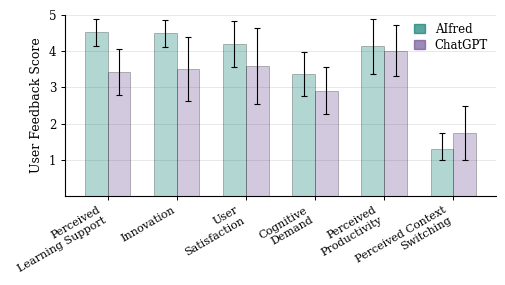

In [83]:
# =========================================================
# MEAN AND STANDARD DEVIATION
# =========================================================

ex_cognitive = EX_qualitative_process['cognitive demand'].mean()
ex_cognitive_sd = EX_qualitative_process['cognitive demand'].std()

ex_learning = EX_qualitative_process['perceived learning support'].mean()
ex_learning_sd = EX_qualitative_process['perceived learning support'].std()

ct_cognitive = CT_qualitative_process['cognitive demand'].mean()
ct_cognitive_sd = CT_qualitative_process['cognitive demand'].std()

ct_learning = CT_qualitative_process['perceived learning support'].mean()
ct_learning_sd = CT_qualitative_process['perceived learning support'].std()

# --- NEW: perceived context switching stats (same source as boxplot) ---
ex_switching_data = EX_percived_context_switching_avg.dropna()
ct_switching_data = CT_percived_context_switching_avg.dropna()

ex_switching = ex_switching_data.mean()
ex_switching_sd = ex_switching_data.std()

ct_switching = ct_switching_data.mean()
ct_switching_sd = ct_switching_data.std()


# =========================================================
# BAR PLOT
# =========================================================

# Tighter spacing between the metrics
x = np.arange(6) * 0.82  # Changed from 3 to 5 metrics

# Slightly narrower bars
width = 0.27

fig, ax = plt.subplots(figsize=(5, 2.75)) # Adjusted figure width for more categories 4.35, 2.75


ex_lower = [ex_learning_sd, ex_sd_z, ex_sd_u, ex_cognitive_sd, ex_sd_w,
            min(ex_switching_sd, ex_switching - 1)]
ex_upper = [ex_learning_sd, ex_sd_z, ex_sd_u, ex_cognitive_sd, ex_sd_w,
            ex_switching_sd]

ct_lower = [ct_learning_sd, ct_sd_z, ct_sd_u, ct_cognitive_sd, ct_sd_w,
            min(ct_switching_sd, ct_switching - 1)]
ct_upper = [ct_learning_sd, ct_sd_z, ct_sd_u, ct_cognitive_sd, ct_sd_w,
            ct_switching_sd]

bars_ex = ax.bar(
    x - width / 2,
    [ex_learning, ex_mean_z, ex_mean_u, ex_cognitive, ex_mean_w, ex_switching],
    width,
    color=COL_EX,
    alpha=0.30,
    edgecolor='black',
    linewidth=0.6,
    yerr=[ex_lower, ex_upper],   # <-- asymmetric now
    capsize=2.5,
    error_kw={'elinewidth': 0.8, 'capthick': 0.8},
    label='AIfred',
    zorder=3
)

bars_ct = ax.bar(
    x + width / 2,
    [ct_learning, ct_mean_z, ct_mean_u, ct_cognitive, ct_mean_w, ct_switching],
    width,
    color=COL_CT,
    alpha=0.30,
    edgecolor='black',
    linewidth=0.6,
    yerr=[ct_lower, ct_upper],   # <-- asymmetric now
    capsize=2.5,
    error_kw={'elinewidth': 0.8, 'capthick': 0.8},
    label='ChatGPT',
    zorder=3
)


# =========================================================
# AXES
# =========================================================

ax.set_xticks(x)

ax.set_xticklabels([
    'Perceived\nLearning Support',
    'Innovation',
    'User\nSatisfaction',
    'Cognitive\nDemand',
    'Perceived\nProductivity',
    'Perceived Context\nSwitching'
], fontsize=8)

plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha='right'
)

ax.set_ylabel('User Feedback Score')

ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])


# =========================================================
# GRID
# =========================================================

ax.grid(
    axis='y',
    color=COL_GRID,
    linewidth=0.6,
    alpha=0.7
)

ax.set_axisbelow(True)


# =========================================================
# SPINES
# =========================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

ax.tick_params(
    width=0.7,
    length=3
)


# =========================================================
# LEGEND
# =========================================================

legend_handles = [
    Patch(
        facecolor=COL_EX,
        edgecolor=COL_EX,
        alpha=0.65,
        label='AIfred'
    ),
    Patch(
        facecolor=COL_CT,
        edgecolor=COL_CT,
        alpha=0.65,
        label='ChatGPT'
    )
]

ax.legend(
    handles=legend_handles,
    loc='upper right',
    fontsize=8.5,
    frameon=False,
    handlelength=1.0,
    handleheight=0.8,
    borderpad=0.15,
    labelspacing=0.25
)


# =========================================================
# LAYOUT
# =========================================================

plt.tight_layout(pad=0.4)

plt.savefig(
    '/content/drive/MyDrive/AIfred/ICRA/DataAnalysis/output_graphs/qualitative.svg',
    format='svg',
    bbox_inches='tight'
)

plt.show()

# **GI**

### <font color="green">time x generation

In [84]:
EX_generate_image_task = pd.DataFrame({
    'task completition time': ex_p['t GI'],
    'number of generations': ex_p['n Generations']
})

CT_generate_image_task = pd.DataFrame({
    'task completition time': ct_p['t GI'],
    'number of generations': ct_p['n Generations']
})

display(EX_generate_image_task)
display(CT_generate_image_task)

,task completition time,number of generations
0,10:00,6
1,00:35,1
2,03:00,2
3,01:20,1
4,01:43,2
5,00:30,1
6,07:39,4
7,03:09,2
8,01:15,1
9,00:39,1


,task completition time,number of generations
18,02:38,1
19,05:20,3
20,02:49,1
21,05:08,1
22,04:28,1
23,05:00,1
24,05:36,4
25,03:27,1
26,03:47,2
27,02:49,1


In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


# =========================================================
# DATA
# =========================================================

EX_generate_image_task = pd.DataFrame({
    'task completion time': ex_p['t GI'],
    'number of generations': ex_p['n Generations']
})

CT_generate_image_task = pd.DataFrame({
    'task completion time': ct_p['t GI'],
    'number of generations': ct_p['n Generations']
})


# =========================================================
# CONVERT TIME TO SECONDS
# =========================================================

EX_generate_image_task['task completion time'] = (
    EX_generate_image_task['task completion time']
    .apply(convert_min_sec_to_seconds)
)

CT_generate_image_task['task completion time'] = (
    CT_generate_image_task['task completion time']
    .apply(convert_min_sec_to_seconds)
)


# =========================================================
# REMOVE MISSING VALUES
# =========================================================

EX_generate_image_task = EX_generate_image_task.dropna()
CT_generate_image_task = CT_generate_image_task.dropna()


# =========================================================
# DISPLAY
# =========================================================

print("AIfred:")
display(EX_generate_image_task)

print("\nChatGPT:")
display(CT_generate_image_task)


# =========================================================
# OVERALL MEANS
# =========================================================

ex_time_mean = EX_generate_image_task['task completion time'].mean()
ex_time_sd = EX_generate_image_task['task completion time'].std()

ex_gen_mean = EX_generate_image_task['number of generations'].mean()
ex_gen_sd = EX_generate_image_task['number of generations'].std()

ct_time_mean = CT_generate_image_task['task completion time'].mean()
ct_time_sd = CT_generate_image_task['task completion time'].std()

ct_gen_mean = CT_generate_image_task['number of generations'].mean()
ct_gen_sd = CT_generate_image_task['number of generations'].std()


# =========================================================
# WELCH'S T-TESTS
# =========================================================

t_time, p_time = stats.ttest_ind(
    EX_generate_image_task['task completion time'],
    CT_generate_image_task['task completion time'],
    equal_var=False
)

t_generations, p_generations = stats.ttest_ind(
    EX_generate_image_task['number of generations'],
    CT_generate_image_task['number of generations'],
    equal_var=False
)


# =========================================================
# PRINT
# =========================================================

print("\n" + "=" * 60)
print("TASK COMPLETION TIME")
print("=" * 60)

print(
    f"AIfred:  M = {ex_time_mean:.2f}s, "
    f"SD = {ex_time_sd:.2f}s"
)

print(
    f"ChatGPT: M = {ct_time_mean:.2f}s, "
    f"SD = {ct_time_sd:.2f}s"
)

print(f"Welch's t-test: p = {p_time:.4f}")


print("\n" + "=" * 60)
print("NUMBER OF GENERATIONS")
print("=" * 60)

print(
    f"AIfred:  M = {ex_gen_mean:.2f}, "
    f"SD = {ex_gen_sd:.2f}"
)

print(
    f"ChatGPT: M = {ct_gen_mean:.2f}, "
    f"SD = {ct_gen_sd:.2f}"
)

print(f"Welch's t-test: p = {p_generations:.4f}")

AIfred:


,task completion time,number of generations
0,600,6
1,35,1
2,180,2
3,80,1
4,103,2
5,30,1
6,459,4
7,189,2
8,75,1
9,39,1



ChatGPT:


,task completion time,number of generations
18,158,1
19,320,3
20,169,1
21,308,1
22,268,1
23,300,1
24,336,4
25,207,1
26,227,2
27,169,1



TASK COMPLETION TIME
AIfred:  M = 167.06s, SD = 156.76s
ChatGPT: M = 208.22s, SD = 74.35s
Welch's t-test: p = 0.3240

NUMBER OF GENERATIONS
AIfred:  M = 2.06, SD = 1.39
ChatGPT: M = 1.50, SD = 1.04
Welch's t-test: p = 0.1851


In [86]:
# =========================================================
# MEAN TIME BY NUMBER OF GENERATIONS
# =========================================================

ex_curve = (
    EX_generate_image_task
    .groupby('number of generations')['task completion time']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

ct_curve = (
    CT_generate_image_task
    .groupby('number of generations')['task completion time']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)


print("\nAIfred generation curve:")
display(ex_curve)

print("\nChatGPT generation curve:")
display(ct_curve)


AIfred generation curve:


,number of generations,mean,std,count
0,1,52.250000,21.325705,8
1,2,170.666667,56.916313,6
2,3,201.000000,NaN,1
3,4,382.000000,108.894444,2
4,6,600.000000,NaN,1



ChatGPT generation curve:


,number of generations,mean,std,count
0,1,184.5,62.929448,14
1,2,227.0,NaN,1
2,3,320.0,NaN,1
3,4,309.0,38.183766,2


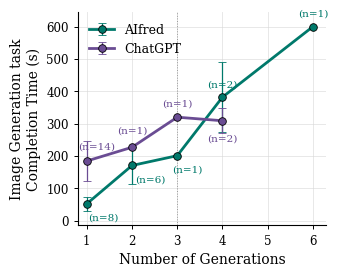

In [87]:
# =========================================================
# COLORS
# =========================================================

COL_EX = '#00796b'
COL_CT = '#6a4c93'
COL_GRID = '#D8D8D8'


# =========================================================
# FONT
# =========================================================

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5
})


# =========================================================
# FIGURE
# =========================================================

fig, ax = plt.subplots(figsize=(3.35, 2.75))


# =========================================================
# OBSERVED DATA
# =========================================================

ex_x = ex_curve['number of generations'].values
ex_y = ex_curve['mean'].values
ex_std = ex_curve['std'].values
ex_n = ex_curve['count'].values

ct_x = ct_curve['number of generations'].values
ct_y = ct_curve['mean'].values
ct_std = ct_curve['std'].values
ct_n = ct_curve['count'].values


# =========================================================
# BACKGROUND SHADING
# =========================================================

# Get sensible vertical limits before adding the shading
all_y = np.concatenate([
    ex_y + np.nan_to_num(ex_std),
    ct_y + np.nan_to_num(ct_std),
    ex_y - np.nan_to_num(ex_std),
    ct_y - np.nan_to_num(ct_std)
])

y_min = np.nanmin(all_y)
y_max = np.nanmax(all_y)

# Add a little padding
y_range = y_max - y_min
shade_ymin = y_min - 0.08 * y_range
shade_ymax = y_max + 0.08 * y_range



# =========================================================
# AIFRED
# =========================================================

ax.errorbar(
    ex_x,
    ex_y,
    yerr=ex_std,
    color=COL_EX,
    linewidth=2.0,
    marker='o',
    markersize=5.5,
    markeredgecolor='black',
    markeredgewidth=0.6,
    capsize=3,
    capthick=0.8,
    elinewidth=0.9,
    label='AIfred',
    zorder=4
)


# =========================================================
# CHATGPT
# =========================================================

ax.errorbar(
    ct_x,
    ct_y,
    yerr=ct_std,
    color=COL_CT,
    linewidth=2.0,
    marker='o',
    markersize=5.5,
    markeredgecolor='black',
    markeredgewidth=0.6,
    capsize=3,
    capthick=0.8,
    elinewidth=0.9,
    label='ChatGPT',
    zorder=4
)


# =========================================================
# N LABELS
# =========================================================

# AIfred labels
for x, y, n in zip(ex_x, ex_y, ex_n):

    if x == 1:
        # 1 generation: more up + right
        offset = (12, -10)

    elif x == 2:
        # 2 generations: below + slightly right
        offset = (13, -10)

    elif x == 3:
        offset = (7, -10)

    else:
        # Default
        offset = (0, 9)

    ax.annotate(
        f'(n={int(n)})',
        xy=(x, y),
        xytext=offset,
        textcoords='offset points',
        ha='center',
        va='center',
        fontsize=7.5,
        color=COL_EX
    )


# ChatGPT labels
for x, y, n in zip(ct_x, ct_y, ct_n):

    if x == 1:
        # 1 generation: slightly down + left
        offset = (7, 10)

    elif x == 2:
        # Default for 2 generations
        offset = (0, 12)

    elif x == 3:
        # 3 generations: down
        offset = (0, 10)

    elif x == 4:
        offset = (0, -13)

    else:
        # Default
        offset = (0, -11)

    ax.annotate(
        f'(n={int(n)})',
        xy=(x, y),
        xytext=offset,
        textcoords='offset points',
        ha='center',
        va='center',
        fontsize=7.5,
        color=COL_CT
    )


# =========================================================
# TRANSITION LINE AT GENERATION 3
# =========================================================

ax.axvline(
    3,
    color='#777777',
    linewidth=0.7,
    linestyle=':',
    alpha=0.7,
    zorder=1
)


# =========================================================
# AXES
# =========================================================

ax.set_xlabel('Number of Generations')
ax.set_ylabel('Image Generation task\nCompletion Time (s)')

ax.set_xlim(
    min(ex_x.min(), ct_x.min()) - 0.2,
    max(ex_x.max(), ct_x.max()) + 0.3
)

ax.set_ylim(
    shade_ymin,
    shade_ymax
)


# =========================================================
# INTEGER X TICKS
# =========================================================

ax.set_xticks(
    np.arange(
        int(min(ex_x.min(), ct_x.min())),
        int(max(ex_x.max(), ct_x.max())) + 1
    )
)


# =========================================================
# GRID
# =========================================================

ax.grid(
    True,
    axis='both',
    color=COL_GRID,
    linewidth=0.6,
    alpha=0.7
)

ax.set_axisbelow(True)


# =========================================================
# SPINES
# =========================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

ax.tick_params(
    width=0.7,
    length=3
)


# =========================================================
# LEGEND
# =========================================================

ax.legend(
    loc='upper left',
    frameon=False,
    fontsize=9,
    handlelength=2.0
)


# =========================================================
# LAYOUT
# =========================================================

plt.tight_layout(pad=0.7)

#plt.savefig(
#    '/content/drive/MyDrive/AIfred/ICRA/DataAnalysis/output_graphs/generateimage_time_projection.svg',
#    format='svg',
#    bbox_inches='tight'
#)

plt.show()

In [88]:
# Assuming your raw per-participant dataframes are something like
# EX_raw and CT_raw, each with a 'number of generations' column

EX_generate_image_task['number of generations'] = EX_generate_image_task['number of generations'].clip(upper=4)
CT_generate_image_task['number of generations'] = CT_generate_image_task['number of generations'].clip(upper=4)

# Then rebuild the aggregated curves as before
ex_curve = (
    EX_generate_image_task.groupby('number of generations')['task completion time']  # adjust col name
    .agg(mean='mean', std='std', count='count')
    .reset_index()
)

ct_curve = (
    CT_generate_image_task.groupby('number of generations')['task completion time']  # adjust col name
    .agg(mean='mean', std='std', count='count')
    .reset_index()
)

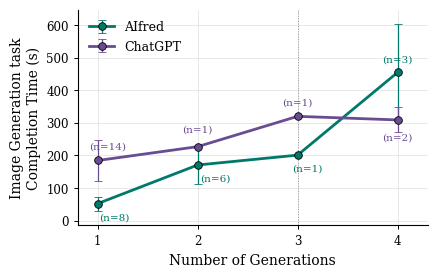

In [89]:
# =========================================================
# COLORS
# =========================================================

COL_EX = '#00796b'
COL_CT = '#6a4c93'
COL_GRID = '#D8D8D8'


# =========================================================
# FONT
# =========================================================

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5
})


# =========================================================
# FIGURE
# =========================================================

fig, ax = plt.subplots(figsize=(4.35, 2.75))


# =========================================================
# OBSERVED DATA
# =========================================================

ex_x = ex_curve['number of generations'].values
ex_y = ex_curve['mean'].values
ex_std = ex_curve['std'].values
ex_n = ex_curve['count'].values

ct_x = ct_curve['number of generations'].values
ct_y = ct_curve['mean'].values
ct_std = ct_curve['std'].values
ct_n = ct_curve['count'].values


# =========================================================
# BACKGROUND SHADING
# =========================================================

# Get sensible vertical limits before adding the shading
all_y = np.concatenate([
    ex_y + np.nan_to_num(ex_std),
    ct_y + np.nan_to_num(ct_std),
    ex_y - np.nan_to_num(ex_std),
    ct_y - np.nan_to_num(ct_std)
])

y_min = np.nanmin(all_y)
y_max = np.nanmax(all_y)

# Add a little padding
y_range = y_max - y_min
shade_ymin = y_min - 0.08 * y_range
shade_ymax = y_max + 0.08 * y_range



# =========================================================
# AIFRED
# =========================================================

ax.errorbar(
    ex_x,
    ex_y,
    yerr=ex_std,
    color=COL_EX,
    linewidth=2.0,
    marker='o',
    markersize=5.5,
    markeredgecolor='black',
    markeredgewidth=0.6,
    capsize=3,
    capthick=0.8,
    elinewidth=0.9,
    label='AIfred',
    zorder=4
)


# =========================================================
# CHATGPT
# =========================================================

ax.errorbar(
    ct_x,
    ct_y,
    yerr=ct_std,
    color=COL_CT,
    linewidth=2.0,
    marker='o',
    markersize=5.5,
    markeredgecolor='black',
    markeredgewidth=0.6,
    capsize=3,
    capthick=0.8,
    elinewidth=0.9,
    label='ChatGPT',
    zorder=4
)


# =========================================================
# N LABELS
# =========================================================

# AIfred labels
for x, y, n in zip(ex_x, ex_y, ex_n):

    if x == 1:
        # 1 generation: more up + right
        offset = (12, -10)

    elif x == 2:
        # 2 generations: below + slightly right
        offset = (13, -10)

    elif x == 3:
        offset = (7, -10)

    else:
        # Default
        offset = (0, 9)

    ax.annotate(
        f'(n={int(n)})',
        xy=(x, y),
        xytext=offset,
        textcoords='offset points',
        ha='center',
        va='center',
        fontsize=7.5,
        color=COL_EX
    )


# ChatGPT labels
for x, y, n in zip(ct_x, ct_y, ct_n):

    if x == 1:
        # 1 generation: slightly down + left
        offset = (7, 10)

    elif x == 2:
        # Default for 2 generations
        offset = (0, 12)

    elif x == 3:
        # 3 generations: down
        offset = (0, 10)

    elif x == 4:
        offset = (0, -13)

    else:
        # Default
        offset = (0, -11)

    ax.annotate(
        f'(n={int(n)})',
        xy=(x, y),
        xytext=offset,
        textcoords='offset points',
        ha='center',
        va='center',
        fontsize=7.5,
        color=COL_CT
    )


# =========================================================
# TRANSITION LINE AT GENERATION 3
# =========================================================

ax.axvline(
    3,
    color='#777777',
    linewidth=0.7,
    linestyle=':',
    alpha=0.7,
    zorder=1
)


# =========================================================
# AXES
# =========================================================

ax.set_xlabel('Number of Generations')
ax.set_ylabel('Image Generation task\nCompletion Time (s)')

ax.set_xlim(
    min(ex_x.min(), ct_x.min()) - 0.2,
    max(ex_x.max(), ct_x.max()) + 0.3
)

ax.set_ylim(
    shade_ymin,
    shade_ymax
)


# =========================================================
# INTEGER X TICKS
# =========================================================

ax.set_xticks(
    np.arange(
        int(min(ex_x.min(), ct_x.min())),
        int(max(ex_x.max(), ct_x.max())) + 1
    )
)


# =========================================================
# GRID
# =========================================================

ax.grid(
    True,
    axis='both',
    color=COL_GRID,
    linewidth=0.6,
    alpha=0.7
)

ax.set_axisbelow(True)


# =========================================================
# SPINES
# =========================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

ax.tick_params(
    width=0.7,
    length=3
)


# =========================================================
# LEGEND
# =========================================================

ax.legend(
    loc='upper left',
    frameon=False,
    fontsize=9,
    handlelength=2.0
)


# =========================================================
# LAYOUT
# =========================================================

plt.tight_layout(pad=0.7)

plt.savefig(
    '/content/drive/MyDrive/AIfred/ICRA/DataAnalysis/output_graphs/generateimage_time_projection.svg',
    format='svg',
    bbox_inches='tight'
)

plt.show()

# **DW**

In [90]:
draw_scores = pd.DataFrame({
    'self-assessed skills': pd.concat([
        ex_p['On a scale form 1 to 10 how confortable are you in drawing?'],
        ct_p['On a scale form 1 to 10 how confortable are you in drawing?']
    ], ignore_index=True),

    'grade with no help': pd.concat([
        ct_p['DW grade in'],
        ex_p['DW grade in']
    ], ignore_index=True),


    'grade with ChatGPT': pd.concat([
        ct_p['DW grade out'],
        ex_p['DW grade out opposite']
    ], ignore_index=True),

    'grade with AIfred': pd.concat([
        ex_p['DW grade out'],
        ct_p['DW grade out opposite']
    ], ignore_index=True)
})

display(draw_scores)

,self-assessed skills,grade with no help,grade with ChatGPT,grade with AIfred
0,3,3,2,1
1,6,3,2,1
2,9,3,2,1
3,9,3,2,1
4,4,3,1,1
5,8,3,2,1
6,8,3,2,2
7,1,3,2,1
8,4,3,2,1
9,3,3,2,1


In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


# =========================================================
# DATA
# =========================================================

draw_scores = pd.DataFrame({
    'self-assessed skills': pd.concat([
        ex_p['On a scale form 1 to 10 how confortable are you in drawing?'],
        ct_p['On a scale form 1 to 10 how confortable are you in drawing?']
    ], ignore_index=True),

    'grade with no help': pd.concat([
        ct_p['DW grade in'],
        ex_p['DW grade in']
    ], ignore_index=True),

    'grade with ChatGPT': pd.concat([
        ct_p['DW grade out'],
        ex_p['DW grade out opposite']
    ], ignore_index=True),

    'grade with AIfred': pd.concat([
        ex_p['DW grade out'],
        ct_p['DW grade out opposite']
    ], ignore_index=True)
})


display(draw_scores)


# =========================================================
# MEANS AND STANDARD DEVIATIONS
# =========================================================

print("=" * 65)
print("DRAWING PERFORMANCE")
print("=" * 65)

for col in draw_scores.columns:
    data = draw_scores[col].dropna()

    print(
        f"{col:25s} "
        f"M = {data.mean():.2f}, "
        f"SD = {data.std():.2f}, "
        f"N = {len(data)}"
    )


# =========================================================
# STATISTICAL TESTS
# =========================================================

# No help vs ChatGPT
no_help_chatgpt = draw_scores[
    ['grade with no help', 'grade with ChatGPT']
].dropna()

t_nohelp_chatgpt, p_nohelp_chatgpt = stats.ttest_rel(
    no_help_chatgpt['grade with no help'],
    no_help_chatgpt['grade with ChatGPT']
)


# No help vs AIfred
no_help_aifred = draw_scores[
    ['grade with no help', 'grade with AIfred']
].dropna()

t_nohelp_aifred, p_nohelp_aifred = stats.ttest_rel(
    no_help_aifred['grade with no help'],
    no_help_aifred['grade with AIfred']
)


# ChatGPT vs AIfred
chatgpt_aifred = draw_scores[
    ['grade with ChatGPT', 'grade with AIfred']
].dropna()

t_chatgpt_aifred, p_chatgpt_aifred = stats.ttest_rel(
    chatgpt_aifred['grade with ChatGPT'],
    chatgpt_aifred['grade with AIfred']
)


# =========================================================
# PRINT P-VALUES
# =========================================================

print("\n" + "=" * 65)
print("PAIRED COMPARISONS")
print("=" * 65)

print(
    f"No help vs ChatGPT: "
    f"t = {t_nohelp_chatgpt:.3f}, "
    f"p = {p_nohelp_chatgpt:.4f}"
)

print(
    f"No help vs AIfred:  "
    f"t = {t_nohelp_aifred:.3f}, "
    f"p = {p_nohelp_aifred:.4f}"
)

print(
    f"ChatGPT vs AIfred:   "
    f"t = {t_chatgpt_aifred:.3f}, "
    f"p = {p_chatgpt_aifred:.4f}"
)


# =========================================================
# IMPROVEMENT RELATIVE TO NO HELP
# =========================================================

baseline = draw_scores['grade with no help']

chatgpt_improvement = (
    (draw_scores['grade with ChatGPT'] - baseline)
    / baseline.replace(0, np.nan)
) * 100

aifred_improvement = (
    (draw_scores['grade with AIfred'] - baseline)
    / baseline.replace(0, np.nan)
) * 100


# Mean participant-level improvement
mean_chatgpt_improvement = chatgpt_improvement.mean()
mean_aifred_improvement = aifred_improvement.mean()


# Cluster / mean-based improvement
mean_no_help = baseline.mean()
mean_chatgpt = draw_scores['grade with ChatGPT'].mean()
mean_aifred = draw_scores['grade with AIfred'].mean()

cluster_chatgpt_improvement = (
    (mean_chatgpt - mean_no_help) / mean_no_help
) * 100

cluster_aifred_improvement = (
    (mean_aifred - mean_no_help) / mean_no_help
) * 100


print("\n" + "=" * 65)
print("IMPROVEMENT RELATIVE TO NO HELP")
print("=" * 65)

print(
    f"ChatGPT: "
    f"{cluster_chatgpt_improvement:+.1f}% "
    f"(mean participant improvement = "
    f"{mean_chatgpt_improvement:+.1f}%)"
)

print(
    f"AIfred:  "
    f"{cluster_aifred_improvement:+.1f}% "
    f"(mean participant improvement = "
    f"{mean_aifred_improvement:+.1f}%)"
)

,self-assessed skills,grade with no help,grade with ChatGPT,grade with AIfred
0,3,3,2,1
1,6,3,2,1
2,9,3,2,1
3,9,3,2,1
4,4,3,1,1
5,8,3,2,1
6,8,3,2,2
7,1,3,2,1
8,4,3,2,1
9,3,3,2,1


DRAWING PERFORMANCE
self-assessed skills      M = 5.25, SD = 2.88, N = 36
grade with no help        M = 2.86, SD = 0.35, N = 36
grade with ChatGPT        M = 2.06, SD = 0.47, N = 36
grade with AIfred         M = 1.08, SD = 0.28, N = 36

PAIRED COMPARISONS
No help vs ChatGPT: t = 6.147, p = 0.0000
No help vs AIfred:  t = 25.298, p = 0.0000
ChatGPT vs AIfred:   t = 10.418, p = 0.0000

IMPROVEMENT RELATIVE TO NO HELP
ChatGPT: -28.2% (mean participant improvement = -24.5%)
AIfred:  -62.1% (mean participant improvement = -61.6%)


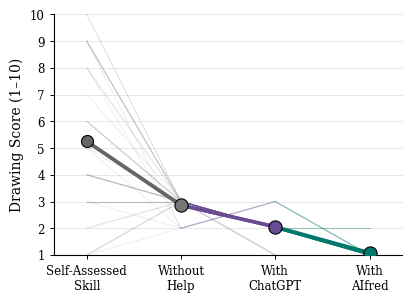

In [92]:
# =========================================================
# COLORS
# =========================================================

COL_EX = '#00796b'
COL_CT = '#6a4c93'
COL_NOHELP = '#777777'
COL_GRID = '#D8D8D8'


# =========================================================
# FONT
# =========================================================

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5
})


# =========================================================
# DATA
# =========================================================

plot_data = draw_scores[
    [
        'self-assessed skills',
        'grade with no help',
        'grade with ChatGPT',
        'grade with AIfred'
    ]
].dropna()


x = np.arange(4)


# =========================================================
# FIGURE
# =========================================================

fig, ax = plt.subplots(figsize=(4.1, 3.0))


# =========================================================
# INDIVIDUAL PARTICIPANT TRAJECTORIES
# =========================================================

for _, row in plot_data.iterrows():

    # -----------------------------------------------------
    # One continuous participant trajectory:
    # Self → No Help → ChatGPT → AIfred
    # -----------------------------------------------------

    # Self-Assessed → Without Help
    ax.plot(
        x[:2],
        row[
            ['self-assessed skills',
             'grade with no help']
        ],
        color='#888888',
        alpha=0.13,
        linewidth=0.8,
        zorder=1
    )

    # Without Help → ChatGPT
    ax.plot(
        x[1:3],
        row[
            ['grade with no help',
             'grade with ChatGPT']
        ],
        color=COL_CT,
        alpha=0.13,
        linewidth=0.8,
        zorder=1
    )

    # ChatGPT → AIfred
    ax.plot(
        x[2:4],
        row[
            ['grade with ChatGPT',
             'grade with AIfred']
        ],
        color=COL_EX,
        alpha=0.13,
        linewidth=0.8,
        zorder=1
    )


# =========================================================
# MEANS
# =========================================================

means = plot_data.mean()

mean_self = means['self-assessed skills']
mean_no_help = means['grade with no help']
mean_chatgpt = means['grade with ChatGPT']
mean_aifred = means['grade with AIfred']


# =========================================================
# MEAN PROGRESSION: SELF → NO HELP
# =========================================================

ax.plot(
    [x[0], x[1]],
    [mean_self, mean_no_help],
    color='#666666',
    linewidth=2.5,
    zorder=4
)


# =========================================================
# MEAN PROGRESSION: NO HELP → CHATGPT
# =========================================================

ax.plot(
    [x[1], x[2]],
    [mean_no_help, mean_chatgpt],
    color=COL_CT,
    linewidth=2.5,
    zorder=4
)


# =========================================================
# MEAN PROGRESSION: SELF → NO HELP → CHATGPT → AIFRED
# =========================================================

# Self → No Help
ax.plot(
    x[:2],
    [mean_self, mean_no_help],
    color='#666666',
    linewidth=2.5,
    zorder=4
)

# No Help → ChatGPT
ax.plot(
    x[1:3],
    [mean_no_help, mean_chatgpt],
    color=COL_CT,
    linewidth=2.5,
    zorder=4
)

# ChatGPT → AIfred
ax.plot(
    x[2:4],
    [mean_chatgpt, mean_aifred],
    color=COL_EX,
    linewidth=2.5,
    zorder=4
)


# =========================================================
# MEAN MARKERS
# =========================================================

ax.scatter(
    x[0],
    mean_self,
    s=75,
    color='#666666',
    edgecolors='black',
    linewidth=0.8,
    zorder=6
)

ax.scatter(
    x[1],
    mean_no_help,
    s=90,
    color='#777777',
    edgecolors='black',
    linewidth=0.8,
    zorder=6
)

ax.scatter(
    x[2],
    mean_chatgpt,
    s=90,
    color=COL_CT,
    edgecolors='black',
    linewidth=0.8,
    zorder=6
)

ax.scatter(
    x[3],
    mean_aifred,
    s=90,
    color=COL_EX,
    edgecolors='black',
    linewidth=0.8,
    zorder=6
)


# =========================================================
# MEAN LABELS
# =========================================================

#ax.annotate(
#    f'{mean_self:.2f}',
#    (x[0], mean_self),
#    xytext=(0, 8),
#    textcoords='offset points',
#    ha='center',
#    va='bottom',
#    fontsize=8.5
#)
#
#ax.annotate(
#    f'{mean_no_help:.2f}',
#    (x[1], mean_no_help),
#    xytext=(0, -13),
#    textcoords='offset points',
#    ha='center',
#    va='top',
#    fontsize=8.5
#)
#
#ax.annotate(
#    f'{mean_chatgpt:.2f}',
#    (x[2], mean_chatgpt),
#    xytext=(0, 8),
#    textcoords='offset points',
#    ha='center',
#    va='bottom',
#    fontsize=8.5
#)
#
#ax.annotate(
#    f'{mean_aifred:.2f}',
#    (x[3], mean_aifred),
#    xytext=(0, 8),
#    textcoords='offset points',
#    ha='center',
#    va='bottom',
#    fontsize=8.5
#)


# =========================================================
# IMPROVEMENT LABELS
# =========================================================

## Position dynamically between baseline and tool means
#chatgpt_label_y = (
#    mean_no_help +
#    0.55 * (mean_chatgpt - mean_no_help)
#)
#
#aifred_label_y = (
#    mean_no_help +
#    0.55 * (mean_aifred - mean_no_help)
#)
#
#
#ax.text(
#    1.50,
#    chatgpt_label_y,
#    f'{cluster_chatgpt_improvement:+.1f}%',
#    color=COL_CT,
#    fontsize=9,
#    fontweight='bold',
#    ha='center',
#    va='center',
#    bbox=dict(
#        facecolor='white',
#        edgecolor='none',
#        alpha=0.8,
#        pad=1.5
#    )
#)
#
#
#ax.text(
#    2.50,
#    aifred_label_y,
#    f'{cluster_aifred_improvement:+.1f}%',
#    color=COL_EX,
#    fontsize=9,
#    fontweight='bold',
#    ha='center',
#    va='center',
#    bbox=dict(
#        facecolor='white',
#        edgecolor='none',
#        alpha=0.8,
#        pad=1.5
#    )
#)
# =========================================================
# AIFRED VS. CHATGPT: KEY RESULT
# =========================================================

#aifred_vs_chatgpt = (
#    (mean_aifred - mean_chatgpt)
#    / mean_chatgpt
#    * 100
#)
#
#ax.text(
#    0.97,
#    0.08,
#    f'AIfred vs. ChatGPT\n'
#    f'↑ {aifred_vs_chatgpt:.1f}%\n'
#    f'$p$ = {p_chatgpt_aifred:.3f}',
#    transform=ax.transAxes,
#    ha='right',
#    va='bottom',
#    fontsize=8.2,
#    color=COL_EX,
#    fontweight='bold',
#    bbox=dict(
#        facecolor='white',
#        edgecolor='none',
#        alpha=0.9,
#        pad=2
#    )
#)

# =========================================================
# AXES
# =========================================================

ax.set_xticks(x)

ax.set_xticklabels([
    'Self-Assessed\nSkill',
    'Without\nHelp',
    'With\nChatGPT',
    'With\nAIfred'
])

ax.set_ylabel('Drawing Score (1–10)')

ax.set_xlim(-0.35, 3.35)
ax.set_ylim(1, 10)


# =========================================================
# GRID
# =========================================================

ax.grid(
    axis='y',
    color=COL_GRID,
    linewidth=0.6,
    alpha=0.7
)

ax.set_axisbelow(True)


# =========================================================
# SPINES
# =========================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

ax.tick_params(
    width=0.7,
    length=3
)


# =========================================================
# P-VALUE SUMMARY
# =========================================================

def format_p(p):
    if p < 0.001:
        return 'p < .001'
    return f'p = {p:.3f}'

#
#ax.text(
#    0.02,
#    0.98,
#    f'Without help → ChatGPT: {format_p(p_nohelp_chatgpt)}\n'
#    f'Without help → AIfred: {format_p(p_nohelp_aifred)}\n'
#    f'ChatGPT → AIfred: {format_p(p_chatgpt_aifred)}',
#    transform=ax.transAxes,
#    fontsize=8.5,
#    va='top',
#    ha='left',
#    bbox=dict(
#        facecolor='white',
#        edgecolor='none',
#        alpha=0.8,
#        pad=2.5
#    )
#)


# =========================================================
# LEGEND
# =========================================================

#from matplotlib.lines import Line2D
#
#legend_handles = [
#    Line2D(
#        [0], [0],
#        color=COL_CT,
#        linewidth=2.5,
#        label='ChatGPT'
#    ),
#    Line2D(
#        [0], [0],
#        color=COL_EX,
#        linewidth=2.5,
#        label='AIfred'
#    ),
#    Line2D(
#        [0], [0],
#        color='#666666',
#        linewidth=2.5,
#        label='Without help'
#    )
#]
#
#ax.legend(
#    handles=legend_handles,
#    loc='lower right',
#    frameon=False,
#    fontsize=8,
#    handlelength=1.8
#)


# =========================================================
# LAYOUT
# =========================================================

plt.tight_layout(pad=0.7)
## Save the figure as an SVG file
#plt.savefig('/content/drive/MyDrive/AIfred/ICRA/DataAnalysis/output_graphs/draw.svg', format='svg', bbox_inches='tight')

plt.show()

Self-Assessed Drawing Skill: M = 5.25, SD = 2.88
Draw Baseline: M = 2.86, SD = 0.35
Draw with ChatGPT: M = 2.06, SD = 0.47
Draw with AIfred: M = 1.08, SD = 0.28


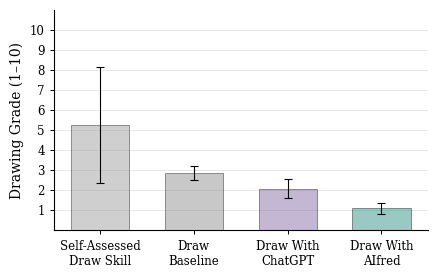

In [93]:
# =========================================================
# COLORS
# =========================================================

COL_EX = '#00796b'
COL_CT = '#6a4c93'
COL_NOHELP = '#777777'
COL_GRID = '#D8D8D8'


# =========================================================
# FONT
# =========================================================

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5
})


# =========================================================
# DATA
# =========================================================

plot_data = draw_scores[
    [
        'self-assessed skills',
        'grade with no help',
        'grade with ChatGPT',
        'grade with AIfred'
    ]
].dropna()


# =========================================================
# MEANS
# =========================================================

means = [
    plot_data['self-assessed skills'].mean(),
    plot_data['grade with no help'].mean(),
    plot_data['grade with ChatGPT'].mean(),
    plot_data['grade with AIfred'].mean()
]

stds = [
    plot_data['self-assessed skills'].std(),
    plot_data['grade with no help'].std(),
    plot_data['grade with ChatGPT'].std(),
    plot_data['grade with AIfred'].std()
]


# =========================================================
# PRINT STATISTICS
# =========================================================

labels = [
    'Self-Assessed Drawing Skill',
    'Draw Baseline',
    'Draw with ChatGPT',
    'Draw with AIfred'
]

for label, mean, std in zip(labels, means, stds):
    print(
        f'{label}: M = {mean:.2f}, SD = {std:.2f}'
    )


# =========================================================
# FIGURE
# =========================================================

fig, ax = plt.subplots(figsize=(4.35, 2.75))

x = np.arange(4)
width = 0.62


# =========================================================
# BARS
# =========================================================

bars = ax.bar(
    x,
    means,
    width=width,
    color=[
        '#888888',
        COL_NOHELP,
        COL_CT,
        COL_EX
    ],
    alpha=0.4,
    edgecolor='black',
    linewidth=0.7,
    yerr=stds,
    capsize=3,
    error_kw={
        'elinewidth': 0.8,
        'capthick': 0.8
    },
    zorder=3
)


# =========================================================
# VALUE LABELS
# =========================================================

#for bar, mean, std in zip(bars, means, stds):
#
#    ax.text(
#        bar.get_x() + bar.get_width() / 2,
#        mean + std + 0.15,
#        f'{mean:.2f}',
#        ha='center',
#        va='bottom',
#        fontsize=8.5
#    )


# =========================================================
# AXES
# =========================================================

ax.set_xticks(x)

ax.set_xticklabels([
    'Self-Assessed\nDraw Skill',
    'Draw\nBaseline',
    'Draw With\nChatGPT',
    'Draw With\nAIfred'
])

ax.set_ylabel('Drawing Grade (1–10)')

ax.set_ylim(0, 11)

ax.set_yticks(np.arange(1, 11, 1))


# =========================================================
# GRID
# =========================================================

ax.grid(
    axis='y',
    color=COL_GRID,
    linewidth=0.6,
    alpha=0.7
)

ax.set_axisbelow(True)


# =========================================================
# SPINES
# =========================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

ax.tick_params(
    width=0.7,
    length=3
)


# =========================================================
# LAYOUT
# =========================================================

plt.tight_layout(pad=0.7)

#plt.savefig(
#    '/content/drive/MyDrive/AIfred/ICRA/DataAnalysis/output_graphs/draw.svg',
#    format='svg',
#    bbox_inches='tight'
#)

plt.show()

grade with no help: 1st=0, 2nd=5, 3rd=31
grade with ChatGPT: 1st=3, 2nd=28, 3rd=5
grade with AIfred: 1st=33, 2nd=3, 3rd=0


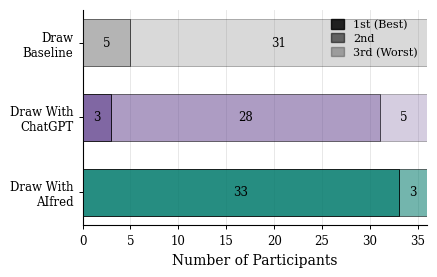

In [94]:
# =========================================================
# COLORS (unchanged)
# =========================================================

COL_EX = '#00796b'
COL_CT = '#6a4c93'
COL_NOHELP = '#777777'
COL_GRID = '#D8D8D8'


# =========================================================
# FONT (unchanged)
# =========================================================

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5
})


# =========================================================
# DATA
# =========================================================
# Columns are now RANKS (1 = best, 3 = worst) among the
# 3 drawings each participant made.

plot_data = draw_scores[
    [
        'grade with no help',
        'grade with ChatGPT',
        'grade with AIfred'
    ]
].dropna()


# =========================================================
# COUNT HOW MANY TIMES EACH CONDITION WAS RANKED 1st/2nd/3rd
# =========================================================

conditions = [
    'grade with no help',
    'grade with ChatGPT',
    'grade with AIfred'
]

labels = [
    'Draw\nBaseline',
    'Draw With\nChatGPT',
    'Draw With\nAIfred'
]

colors = [COL_NOHELP, COL_CT, COL_EX]

# counts[condition] = [count_rank1, count_rank2, count_rank3]
counts = {
    cond: [
        (plot_data[cond] == rank).sum()
        for rank in [1, 2, 3]
    ]
    for cond in conditions
}

for cond in conditions:
    print(f'{cond}: 1st={counts[cond][0]}, '
          f'2nd={counts[cond][1]}, '
          f'3rd={counts[cond][2]}')


# =========================================================
# FIGURE
# =========================================================

fig, ax = plt.subplots(figsize=(4.35, 2.75))

y = np.arange(len(conditions))
bar_height = 0.62

# Alpha per rank: 1st place most opaque, 3rd place most transparent
rank_alphas = [0.85, 0.55, 0.28]
rank_labels = ['1st (Best)', '2nd', '3rd (Worst)']


# =========================================================
# STACKED HORIZONTAL BARS
# =========================================================

left = np.zeros(len(conditions))

bars_by_rank = []

for rank_idx in range(3):

    values = [counts[cond][rank_idx] for cond in conditions]

    bars = ax.barh(
        y,
        values,
        height=bar_height,
        left=left,
        color=colors,
        alpha=rank_alphas[rank_idx],
        edgecolor='black',
        linewidth=0.7,
        zorder=3
    )

    bars_by_rank.append(bars)

    left += np.array(values)


# =========================================================
# COUNT LABELS INSIDE SEGMENTS
# =========================================================

left = np.zeros(len(conditions))

for rank_idx in range(3):

    values = [counts[cond][rank_idx] for cond in conditions]

    for i, v in enumerate(values):
        if v > 0:
            ax.text(
                left[i] + v / 2,
                y[i],
                str(v),
                ha='center',
                va='center',
                fontsize=8.5,
                color='black'
            )

    left += np.array(values)


# =========================================================
# AXES
# =========================================================

ax.set_yticks(y)
ax.set_yticklabels(labels)

ax.set_xlabel('Number of Participants')

ax.invert_yaxis()  # baseline on top, matches original left-to-right order


# =========================================================
# GRID
# =========================================================

ax.grid(
    axis='x',
    color=COL_GRID,
    linewidth=0.6,
    alpha=0.7
)

ax.set_axisbelow(True)


# =========================================================
# SPINES
# =========================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

ax.tick_params(
    width=0.7,
    length=3
)


# =========================================================
# LEGEND (rank meaning, using neutral grey swatches)
# =========================================================

legend_handles = [
    Patch(
        facecolor='black',
        alpha=rank_alphas[i],
        edgecolor='black',
        label=rank_labels[i]
    )
    for i in range(3)
]

ax.legend(
    handles=legend_handles,
    loc='upper right',
    frameon=False,
    fontsize=8,
    handlelength=1.2,
    handleheight=0.9,
    labelspacing=0.3
)


# =========================================================
# LAYOUT
# =========================================================

plt.tight_layout(pad=0.7)

plt.savefig(
    '/content/drive/MyDrive/AIfred/ICRA/DataAnalysis/output_graphs/draw.svg',
    format='svg',
    bbox_inches='tight'
)

plt.show()

N participants: 36
Total judgments (participants x professors): 108

MEAN RANK PER CONDITION (lower = better, pooled across professors)
baseline  : M = 2.833, SD = 0.374
chatgpt   : M = 2.037, SD = 0.546
aifred    : M = 1.130, SD = 0.337

RANK COUNTS (pooled across all 3 professors, N=108 judgments)
baseline  : 1st =   0 (  0.0%)  2nd =  18 ( 16.7%)  3rd =  90 ( 83.3%)
chatgpt   : 1st =  14 ( 13.0%)  2nd =  76 ( 70.4%)  3rd =  18 ( 16.7%)
aifred    : 1st =  94 ( 87.0%)  2nd =  14 ( 13.0%)  3rd =   0 (  0.0%)

INTER-RATER AGREEMENT (Kendall's W, 0=no agreement, 1=perfect)
Mean W across 36 participants: 0.864

FRIEDMAN TEST (overall difference across baseline/ChatGPT/AIfred)
chi2 = 156.963, p = 0.00000

PAIRWISE WILCOXON SIGNED-RANK TESTS (post-hoc)
baseline vs chatgpt: W = 855.000, p = 0.00000
baseline vs aifred: W = 0.000, p = 0.00000
chatgpt vs aifred: W = 637.000, p = 0.00000


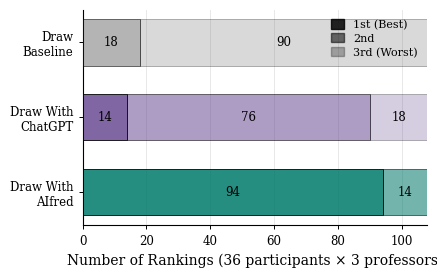

In [95]:
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon

# =========================================================
# COLORS (kept consistent with your other figures)
# =========================================================

COL_EX = '#00796b'
COL_CT = '#6a4c93'
COL_NOHELP = '#777777'
COL_GRID = '#D8D8D8'


# =========================================================
# LOAD DATA
# =========================================================

df = pd.read_csv(partecipants_db_path)
df.columns = [c.strip().lower() for c in df.columns]

n_participants = len(df)
print(f"N participants: {n_participants}")


# =========================================================
# RESHAPE: long format, one row per (participant, professor)
# =========================================================
# Each row = one professor's judgment of one participant's 3 drawings

rows = []
for i, row in df.iterrows():
    for p in [1, 2, 3]:
        rows.append({
            'participant': i,
            'professor': p,
            'baseline': row[f'baseline rank p{p}'],
            'chatgpt': row[f'chat gpt rank p{p}'],
            'aifred': row[f'aifred rank p{p}']
        })

long_df = pd.DataFrame(rows)

print(f"Total judgments (participants x professors): {len(long_df)}")


# =========================================================
# DESCRIPTIVE STATS: mean rank per condition
# =========================================================

print("\n" + "=" * 65)
print("MEAN RANK PER CONDITION (lower = better, pooled across professors)")
print("=" * 65)

for cond in ['baseline', 'chatgpt', 'aifred']:
    m = long_df[cond].mean()
    sd = long_df[cond].std()
    print(f"{cond:10s}: M = {m:.3f}, SD = {sd:.3f}")


# =========================================================
# COUNTS: how many times each condition was ranked 1st/2nd/3rd
# =========================================================

print("\n" + "=" * 65)
print("RANK COUNTS (pooled across all 3 professors, N=108 judgments)")
print("=" * 65)

counts = {}
for cond in ['baseline', 'chatgpt', 'aifred']:
    c1 = (long_df[cond] == 1).sum()
    c2 = (long_df[cond] == 2).sum()
    c3 = (long_df[cond] == 3).sum()
    counts[cond] = [c1, c2, c3]
    total = c1 + c2 + c3
    print(
        f"{cond:10s}: 1st = {c1:3d} ({c1/total*100:5.1f}%)  "
        f"2nd = {c2:3d} ({c2/total*100:5.1f}%)  "
        f"3rd = {c3:3d} ({c3/total*100:5.1f}%)"
    )


# =========================================================
# INTER-RATER AGREEMENT: Kendall's W per participant
# =========================================================

def kendalls_w(rank_matrix):
    """rank_matrix: shape (n_raters, k_items)"""
    n, k = rank_matrix.shape
    rank_sums = rank_matrix.sum(axis=0)
    mean_rank = rank_sums.mean()
    ss = np.sum((rank_sums - mean_rank) ** 2)
    return (12 * ss) / (n ** 2 * (k ** 3 - k))

w_values = []
for i, row in df.iterrows():
    matrix = np.array([
        [row[f'baseline rank p{p}'], row[f'chat gpt rank p{p}'], row[f'aifred rank p{p}']]
        for p in [1, 2, 3]
    ])
    w_values.append(kendalls_w(matrix))

print("\n" + "=" * 65)
print("INTER-RATER AGREEMENT (Kendall's W, 0=no agreement, 1=perfect)")
print("=" * 65)
print(f"Mean W across {n_participants} participants: {np.mean(w_values):.3f}")


# =========================================================
# FRIEDMAN TEST: do the 3 conditions differ overall?
# =========================================================
# Blocks = participant x professor judgments (N=108)

stat, p_friedman = friedmanchisquare(
    long_df['baseline'],
    long_df['chatgpt'],
    long_df['aifred']
)

print("\n" + "=" * 65)
print("FRIEDMAN TEST (overall difference across baseline/ChatGPT/AIfred)")
print("=" * 65)
print(f"chi2 = {stat:.3f}, p = {p_friedman:.5f}")


# =========================================================
# POST-HOC: pairwise Wilcoxon signed-rank tests
# =========================================================

print("\n" + "=" * 65)
print("PAIRWISE WILCOXON SIGNED-RANK TESTS (post-hoc)")
print("=" * 65)

pairs = [
    ('baseline', 'chatgpt'),
    ('baseline', 'aifred'),
    ('chatgpt', 'aifred')
]

for a, b in pairs:
    stat_w, p_w = wilcoxon(long_df[a], long_df[b])
    print(f"{a} vs {b}: W = {stat_w:.3f}, p = {p_w:.5f}")


# =========================================================
# FIGURE: stacked horizontal bar (same format as your draw.svg)
# =========================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5
})

conditions = ['baseline', 'chatgpt', 'aifred']
labels = ['Draw\nBaseline', 'Draw With\nChatGPT', 'Draw With\nAIfred']
colors = [COL_NOHELP, COL_CT, COL_EX]

rank_alphas = [0.85, 0.55, 0.28]
rank_labels = ['1st (Best)', '2nd', '3rd (Worst)']

fig, ax = plt.subplots(figsize=(4.35, 2.75))

y = np.arange(len(conditions))
bar_height = 0.62

left = np.zeros(len(conditions))

for rank_idx, rank_val in enumerate([1, 2, 3]):
    values = [counts[cond][rank_idx] for cond in conditions]

    ax.barh(
        y,
        values,
        height=bar_height,
        left=left,
        color=colors,
        alpha=rank_alphas[rank_idx],
        edgecolor='black',
        linewidth=0.7,
        zorder=3
    )

    for i, v in enumerate(values):
        if v > 0:
            ax.text(
                left[i] + v / 2,
                y[i],
                str(v),
                ha='center',
                va='center',
                fontsize=8.5,
                color='black'
            )

    left += np.array(values)

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel('Number of Rankings (36 participants \u00d7 3 professors)')
ax.invert_yaxis()

ax.grid(axis='x', color=COL_GRID, linewidth=0.6, alpha=0.7)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(width=0.7, length=3)

legend_handles = [
    Patch(facecolor='black', alpha=rank_alphas[i], edgecolor='black', label=rank_labels[i])
    for i in range(3)
]

ax.legend(
    handles=legend_handles,
    loc='upper right',
    frameon=False,
    fontsize=8,
    handlelength=1.2,
    handleheight=0.9,
    labelspacing=0.3
)

plt.tight_layout(pad=0.7)
plt.savefig(
    '/content/drive/MyDrive/AIfred/ICRA/DataAnalysis/output_graphs/draw_rank_counts.svg',
    format='svg',
    bbox_inches='tight'
)
plt.show()

N participants: 36
Participants where median ranks form a clean 1/2/3 ordering: 36/36

MEDIAN RANK PER CONDITION (N=36 participants)
baseline  : mean-of-medians = 2.861, SD = 0.351
chatgpt   : mean-of-medians = 2.056, SD = 0.475
aifred    : mean-of-medians = 1.083, SD = 0.280

RANK COUNTS (based on median rank, N=36 participants)
baseline  : 1st =  0 (  0.0%)  2nd =  5 ( 13.9%)  3rd = 31 ( 86.1%)
chatgpt   : 1st =  3 (  8.3%)  2nd = 28 ( 77.8%)  3rd =  5 ( 13.9%)
aifred    : 1st = 33 ( 91.7%)  2nd =  3 (  8.3%)  3rd =  0 (  0.0%)

FRIEDMAN TEST on participant-level median ranks (N=36)
chi2 = 57.056, p = 0.00000

PAIRWISE WILCOXON SIGNED-RANK TESTS (N=36)
baseline vs chatgpt: W = 85.000, p = 0.00002
baseline vs aifred: W = 0.000, p = 0.00000
chatgpt vs aifred: W = 48.000, p = 0.00000


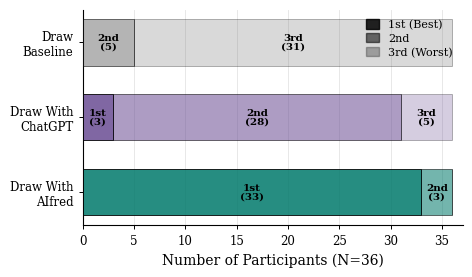

In [96]:
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =========================================================
# COLORS
# =========================================================

COL_EX = '#00796b'
COL_CT = '#6a4c93'
COL_NOHELP = '#777777'
COL_GRID = '#D8D8D8'

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5
})


# =========================================================
# LOAD DATA
# =========================================================

df = pd.read_csv(partecipants_db_path)
df.columns = [c.strip().lower() for c in df.columns]

n_participants = len(df)


# =========================================================
# MEDIAN RANK PER PARTICIPANT (majority vote across 3 professors)
# =========================================================

median_df = pd.DataFrame({
    'baseline': df[['baseline rank p1', 'baseline rank p2', 'baseline rank p3']].median(axis=1),
    'chatgpt':  df[['chat gpt rank p1', 'chat gpt rank p2', 'chat gpt rank p3']].median(axis=1),
    'aifred':   df[['aifred rank p1', 'aifred rank p2', 'aifred rank p3']].median(axis=1),
})

# --- Sanity check: do the 3 medians form a valid 1/2/3 ranking? ---
# (they should almost always, given high inter-rater agreement)
valid_ranking = median_df.apply(
    lambda row: sorted(row.values) == [1.0, 2.0, 3.0], axis=1
)
n_invalid = (~valid_ranking).sum()

print(f"N participants: {n_participants}")
print(f"Participants where median ranks form a clean 1/2/3 ordering: "
      f"{valid_ranking.sum()}/{n_participants}")
if n_invalid > 0:
    print(f"  ({n_invalid} participants have a tie in the median rank — "
          f"inspect these manually if needed)")


# =========================================================
# DESCRIPTIVE STATS (N=36)
# =========================================================

print("\n" + "=" * 65)
print("MEDIAN RANK PER CONDITION (N=36 participants)")
print("=" * 65)

for cond in ['baseline', 'chatgpt', 'aifred']:
    m = median_df[cond].mean()      # mean of the medians, for a summary stat
    sd = median_df[cond].std()
    print(f"{cond:10s}: mean-of-medians = {m:.3f}, SD = {sd:.3f}")


# =========================================================
# RANK COUNTS (N=36)
# =========================================================

print("\n" + "=" * 65)
print("RANK COUNTS (based on median rank, N=36 participants)")
print("=" * 65)

conditions = ['baseline', 'chatgpt', 'aifred']
labels = ['Draw\nBaseline', 'Draw With\nChatGPT', 'Draw With\nAIfred']
colors = [COL_NOHELP, COL_CT, COL_EX]

counts = {}
for cond in conditions:
    c1 = (median_df[cond] == 1).sum()
    c2 = (median_df[cond] == 2).sum()
    c3 = (median_df[cond] == 3).sum()
    counts[cond] = [c1, c2, c3]
    total = c1 + c2 + c3
    print(
        f"{cond:10s}: 1st = {c1:2d} ({c1/total*100:5.1f}%)  "
        f"2nd = {c2:2d} ({c2/total*100:5.1f}%)  "
        f"3rd = {c3:2d} ({c3/total*100:5.1f}%)"
    )


# =========================================================
# FRIEDMAN TEST (N=36, the primary/conservative test)
# =========================================================

stat, p_friedman = friedmanchisquare(
    median_df['baseline'],
    median_df['chatgpt'],
    median_df['aifred']
)

print("\n" + "=" * 65)
print("FRIEDMAN TEST on participant-level median ranks (N=36)")
print("=" * 65)
print(f"chi2 = {stat:.3f}, p = {p_friedman:.5f}")


# =========================================================
# POST-HOC WILCOXON (N=36)
# =========================================================

print("\n" + "=" * 65)
print("PAIRWISE WILCOXON SIGNED-RANK TESTS (N=36)")
print("=" * 65)

for a, b in [('baseline', 'chatgpt'), ('baseline', 'aifred'), ('chatgpt', 'aifred')]:
    stat_w, p_w = wilcoxon(median_df[a], median_df[b])
    print(f"{a} vs {b}: W = {stat_w:.3f}, p = {p_w:.5f}")


# =========================================================
# FIGURE — stacked bars, N=36, with DIRECT segment labels
# =========================================================

rank_alphas = [0.85, 0.55, 0.28]
rank_names = ['1st', '2nd', '3rd']
hatches = [None, None, None]   # Removed stripes

fig, ax = plt.subplots(figsize=(4.7, 2.75))

y = np.arange(len(conditions))
bar_height = 0.62

left = np.zeros(len(conditions))

for rank_idx in range(3):
    values = [counts[cond][rank_idx] for cond in conditions]

    ax.barh(
        y,
        values,
        height=bar_height,
        left=left,
        color=colors,
        alpha=rank_alphas[rank_idx],
        edgecolor='black',
        linewidth=0.7,
        hatch=hatches[rank_idx],
        zorder=3
    )

    # Direct label inside each segment: "1st\n(24)" style
    for i, v in enumerate(values):
        if v > 0:
            ax.text(
                left[i] + v / 2,
                y[i],
                f'{rank_names[rank_idx]}\n({v})',
                ha='center',
                va='center',
                fontsize=7.5,
                fontweight='bold',
                color='black',
                linespacing=0.9
            )

    left += np.array(values)

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel('Number of Participants (N=36)')
ax.set_xlim(0, n_participants + 1)
ax.invert_yaxis()

ax.grid(axis='x', color=COL_GRID, linewidth=0.6, alpha=0.7)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(width=0.7, length=3)

# No separate legend needed — labels are directly on the bars.
# Optional: keep a minimal one for print/grayscale clarity.
legend_handles = [
    Patch(facecolor='black', alpha=rank_alphas[i], edgecolor='black', label=rank_labels[i])
    for i in range(3)
]

ax.legend(
    handles=legend_handles,
    loc='upper right',
    frameon=False,
    fontsize=8,
    handlelength=1.2,
    handleheight=0.9,
    labelspacing=0.3
)

plt.tight_layout(pad=0.7)
plt.savefig(
    '/content/drive/MyDrive/AIfred/ICRA/DataAnalysis/output_graphs/draw_rank_counts_median.svg',
    format='svg',
    bbox_inches='tight'
)
plt.show()

# **Demographic**

Age distribution:
Age
< 18        4
19 - 25    19
26 - 35     8
36 - 45     4
45+         1
Name: count, dtype: int64

N = 36


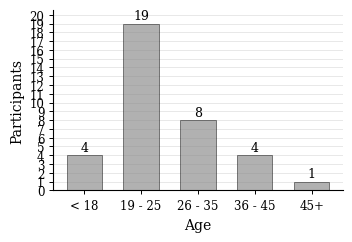

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# COLORS
# =========================================================

COL_EX = '#00796b'
COL_CT = '#6a4c93'
COL_GRID = '#D8D8D8'


# =========================================================
# DATA
# =========================================================

AGE_COL = 'Age'

age_order = [
    '< 18',
    '19 - 25',
    '26 - 35',
    '36 - 45',
    '45+'
]

age_counts = (
    p_db[AGE_COL]
    .astype(str)
    .str.strip()
    .value_counts()
    .reindex(age_order, fill_value=0)
)

print("Age distribution:")
print(age_counts)

print(f"\nN = {age_counts.sum()}")


# =========================================================
# FIGURE
# =========================================================

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5
})

fig, ax = plt.subplots(figsize=(3.5, 2.4))

# =========================================================
# BARS
# =========================================================

x = np.arange(len(age_order))

bars = ax.bar(
    x,
    age_counts.values,
    width=0.62,
    color='#888888',
    alpha=0.65,
    edgecolor='black',
    linewidth=0.5
)


# =========================================================
# VALUE LABELS
# =========================================================

for bar, count in zip(bars, age_counts.values):

    if count > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.15,
            f'{count}',
            ha='center',
            va='bottom',
            fontsize=9
        )


# =========================================================
# AXES
# =========================================================

ax.set_xticks(x)
ax.set_xticklabels(age_order)

ax.set_xlabel('Age')
ax.set_ylabel('Participants')

ax.set_ylim(
    0,
    max(age_counts.values) + 1.5
)

# Integer y-axis
ax.set_yticks(
    np.arange(
        0,
        max(age_counts.values) + 2,
        1
    )
)


# =========================================================
# GRID
# =========================================================

ax.grid(
    True,
    axis='y',
    color=COL_GRID,
    linewidth=0.6,
    alpha=0.7
)

ax.set_axisbelow(True)


# =========================================================
# SPINES
# =========================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

ax.tick_params(
    width=0.7,
    length=3
)


# =========================================================
# LAYOUT
# =========================================================

plt.tight_layout(pad=0.7)

#plt.savefig(
#    '/content/drive/MyDrive/AIfred/ICRA/DataAnalysis/output_graphs/'
#    'participant_age.svg',
#    format='svg',
#    bbox_inches='tight'
#)

plt.show()

In [98]:
gender_counts = p_db['Gender'].value_counts()
print("Gender distribution:")
print(gender_counts)

Gender distribution:
Gender
Female    19
Male      17
Name: count, dtype: int64


In [99]:
ROBOTICS_COL = 'On a scale form 1 to 10 how familar are you with robotics systems?'
AI_COL = 'On a scale form 1 to 10 how familar are you with AI systems?'

robotics_avg = p_db[ROBOTICS_COL].mean()
ai_avg = p_db[AI_COL].mean()

print(f"Average familiarity with robotics: {robotics_avg:.2f}/10")
print(f"Average familiarity with AI: {ai_avg:.2f}/10")

Average familiarity with robotics: 5.78/10
Average familiarity with AI: 7.08/10


In [100]:
print(
    f"Robotics familiarity: M = {p_db[ROBOTICS_COL].mean():.2f}, "
    f"SD = {p_db[ROBOTICS_COL].std():.2f}, "
    f"N = {p_db[ROBOTICS_COL].count()}"
)

print(
    f"AI familiarity: M = {p_db[AI_COL].mean():.2f}, "
    f"SD = {p_db[AI_COL].std():.2f}, "
    f"N = {p_db[AI_COL].count()}"
)

Robotics familiarity: M = 5.78, SD = 3.53, N = 36
AI familiarity: M = 7.08, SD = 2.30, N = 36


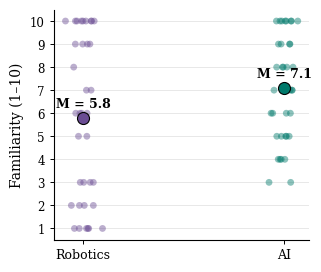

In [101]:
import numpy as np
import matplotlib.pyplot as plt

ROBOTICS_COL = 'On a scale form 1 to 10 how familar are you with robotics systems?'
AI_COL = 'On a scale form 1 to 10 how familar are you with AI systems?'

robotics = p_db[ROBOTICS_COL].dropna()
ai = p_db[AI_COL].dropna()

values = [robotics, ai]
labels = ['Robotics', 'AI']

COL_EX = '#00796b'
COL_CT = '#6a4c93'
COL_GRID = '#D8D8D8'

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 8.5
})

fig, ax = plt.subplots(figsize=(3.2, 2.7))

x = np.arange(2)

rng = np.random.default_rng(42)

# Individual participants
for i, vals in enumerate(values):

    jitter = rng.normal(0, 0.045, len(vals))

    ax.scatter(
        np.full(len(vals), x[i]) + jitter,
        vals,
        s=24,
        color=[COL_CT, COL_EX][i],
        alpha=0.45,
        edgecolors='none',
        zorder=2
    )

# Means
for i, vals in enumerate(values):

    mean = vals.mean()

    ax.scatter(
        x[i],
        mean,
        s=75,
        color=[COL_CT, COL_EX][i],
        edgecolor='black',
        linewidth=0.8,
        zorder=5
    )

    ax.text(
        x[i],
        mean + 0.35,
        f'M = {mean:.1f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Axes
ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel('Familiarity (1–10)')

ax.set_ylim(0.5, 10.5)
ax.set_yticks(np.arange(1, 11, 1))

# Grid
ax.grid(
    True,
    axis='y',
    color=COL_GRID,
    linewidth=0.6,
    alpha=0.7
)

ax.set_axisbelow(True)

# Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

ax.tick_params(
    width=0.7,
    length=3
)

plt.tight_layout(pad=0.7)

#plt.savefig(
#    '/content/drive/MyDrive/AIfred/ICRA/DataAnalysis/output_graphs/'
#    'participant_technology_familiarity.svg',
#    format='svg',
#    bbox_inches='tight'
#)

plt.show()